## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../../../')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import scipy
import pandas as pd
import cupy as cp
import seaborn as sns
from __future__ import annotations

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, make_scorer
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict

from dataclasses import dataclass

import pyaldata as pyal

import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors
import tools.reports as reports
import tools.kinematics as kin


from tqdm import tqdm
import pickle

from joblib import Parallel, delayed
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import cross_validate, KFold, StratifiedKFold, RepeatedStratifiedKFold
from sklearn.naive_bayes import GaussianNB

from pathlib import Path

In [3]:
def load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f)


In [4]:
# ── Parameters — edit these to select what to plot ───────────────────────────
RESULTS_DIR = Path('/data/equake_results/lagged_kin_dec_no_smoothing/')
SESSION     = 'M061_2025_03_06_14_00'
AREA        = 'MOp'
KEYPOINT    = 'left_elbow'

# Visualisation windows
BASELINE_S  = (-1.0, -0.3)
SPAGHETTI_S = (-0.1,  0.5)

# List available files
files = sorted(RESULTS_DIR.glob('lagged_dec_*.pkl'))
print(f'Found {len(files)} result files:')
for f in files:
    print(f'  {f.name}')


Found 39 result files:
  lagged_dec_CP_M061_2025_03_04_10_00_npcs30.pkl
  lagged_dec_CP_M061_2025_03_05_14_00_npcs30.pkl
  lagged_dec_CP_M061_2025_03_06_14_00_npcs30.pkl
  lagged_dec_CP_M062_2025_03_20_14_00_npcs30.pkl
  lagged_dec_CP_M062_2025_03_21_14_00_npcs30.pkl
  lagged_dec_CP_M078_2025_08_06_15_00_npcs30.pkl
  lagged_dec_CP_M086_2025_12_10_15_00_npcs30.pkl
  lagged_dec_MOp_M061_2025_03_04_10_00_npcs100.pkl
  lagged_dec_MOp_M061_2025_03_04_10_00_npcs25.pkl
  lagged_dec_MOp_M061_2025_03_05_14_00_npcs100.pkl
  lagged_dec_MOp_M061_2025_03_05_14_00_npcs25.pkl
  lagged_dec_MOp_M061_2025_03_06_14_00_npcs100.pkl
  lagged_dec_MOp_M061_2025_03_06_14_00_npcs25.pkl
  lagged_dec_MOp_M062_2025_03_20_14_00_npcs100.pkl
  lagged_dec_MOp_M062_2025_03_20_14_00_npcs25.pkl
  lagged_dec_MOp_M062_2025_03_21_14_00_npcs100.pkl
  lagged_dec_MOp_M062_2025_03_21_14_00_npcs25.pkl
  lagged_dec_MOp_M078_2025_08_06_15_00_npcs25.pkl
  lagged_dec_MOp_M078_2025_08_06_15_00_npcs83.pkl
  lagged_dec_MOp_M086_2025_12

In [5]:
# ── Load all areas for SESSION ────────────────────────────────────────────────
# session_data[area] = data dict from pickle
session_data = {}

for f in sorted(RESULTS_DIR.glob(f'lagged_dec_*_{SESSION}_npcs*.pkl')):
    area = f.name.split('_')[2]  # lagged_dec_<AREA>_<SESSION>_npcs<N>.pkl
    session_data[area] = load_pkl(f)
    n = session_data[area]['_meta']['n_pcs']
    kps = [k for k in session_data[area] if k != '_meta']
    print(f"  {area:5s} | {n:3d} PCs | {len(kps)} keypoints")

print(f"\nLoaded areas: {list(session_data.keys())}")

# shared metadata (same across areas)
_meta0    = next(iter(session_data.values()))['_meta']
lags_s    = _meta0['lags_s']
keypoints = [k for k in next(iter(session_data.values())) if k != '_meta']
all_t     = np.array(sorted(session_data[list(session_data.keys())[0]][keypoints[0]].keys()))

bl_mask  = (all_t >= BASELINE_S[0]) & (all_t <  BASELINE_S[1])
sp_mask  = (all_t >= SPAGHETTI_S[0]) & (all_t <= SPAGHETTI_S[1])
sp_t     = all_t[sp_mask]
lag0_idx = np.argmin(np.abs(lags_s))

print(f"Lags     : {lags_s[0]:.2f} → {lags_s[-1]:.2f} s  ({len(lags_s)} steps)")
print(f"Time pts : {len(all_t)}  |  baseline: {bl_mask.sum()}  |  spaghetti: {sp_mask.sum()}")
print(f"Lag 0    : {lags_s[lag0_idx]:.3f} s  (idx {lag0_idx})")


  CP    |  30 PCs | 19 keypoints
  MOp   | 100 PCs | 4 keypoints
  MOp   |  25 PCs | 19 keypoints
  SSp   |  15 PCs | 19 keypoints
  SSp   |  60 PCs | 4 keypoints
  VAL   |  50 PCs | 19 keypoints

Loaded areas: ['CP', 'MOp', 'SSp', 'VAL']
Lags     : -0.15 → 0.15 s  (31 steps)
Time pts : 100  |  baseline: 25  |  spaghetti: 30
Lag 0    : 0.000 s  (idx 15)


# Lag 0 results

MOp: mat shape (19, 100),  vmax=15.85


KeyError: 'left_shoulder'

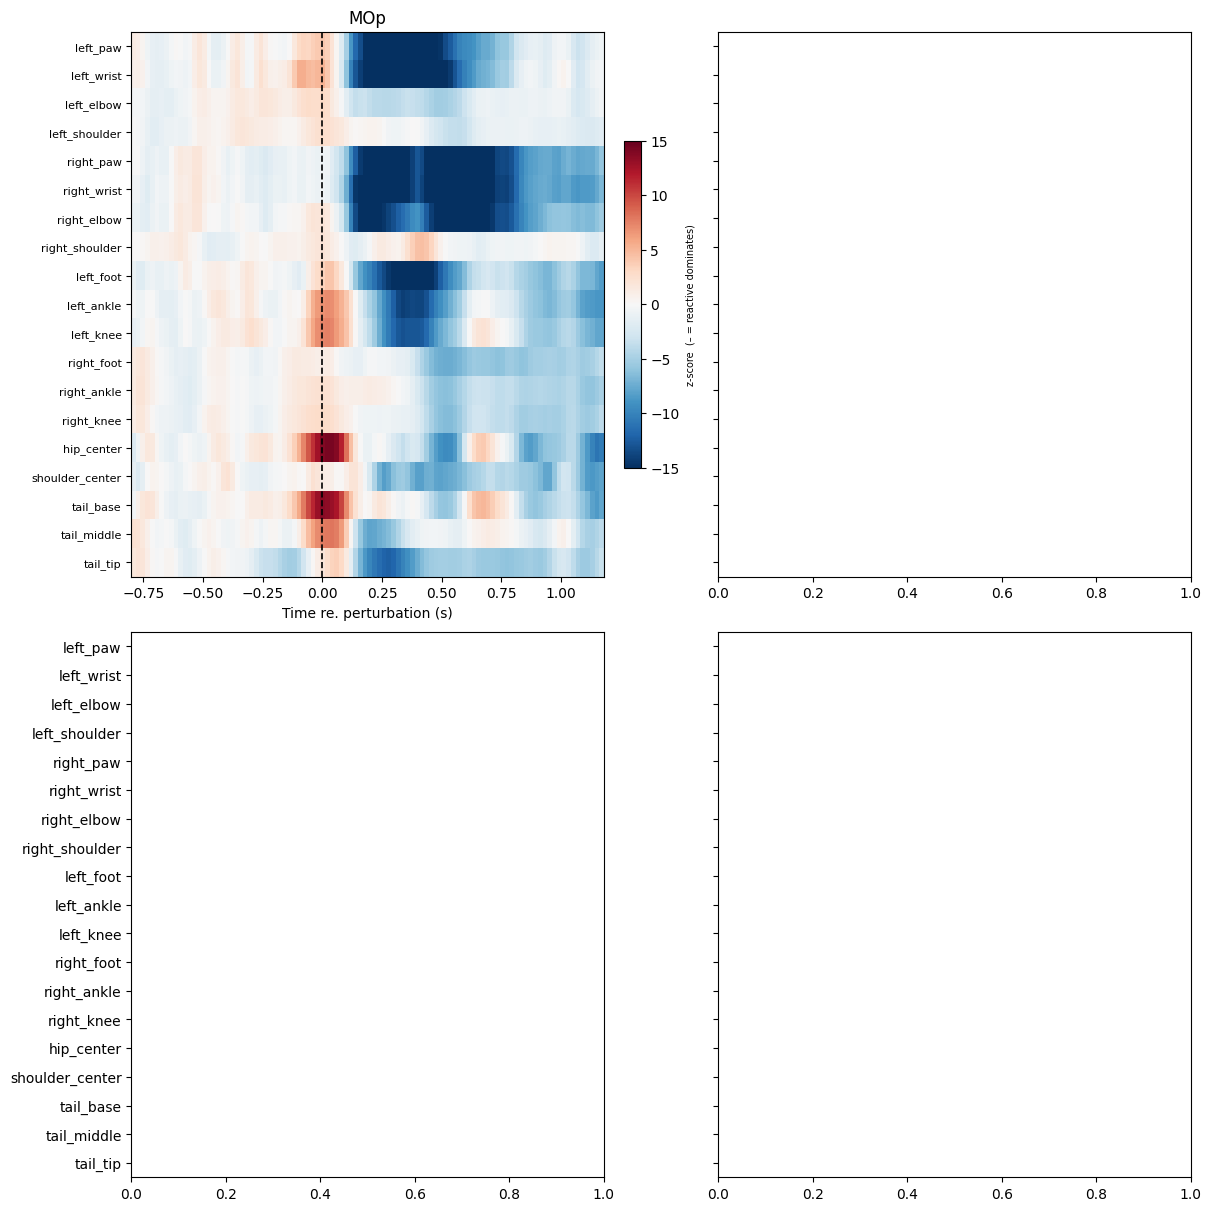

In [6]:

# ── Heatmap: baseline z-scored R² at lag 0 over time, one per area ────────────
AREAS_PLOT = [a for a in ['MOp', 'SSp', 'CP', 'VAL'] if a in session_data]

KP_ORDER_ALL = [
    'left_paw',  'left_wrist',  'left_elbow',  'left_shoulder',
    'right_paw', 'right_wrist', 'right_elbow', 'right_shoulder',
    'left_foot',  'left_ankle',  'left_knee',
    'right_foot', 'right_ankle', 'right_knee',
    'hip_center', 'shoulder_center', 'tail_base', 'tail_middle', 'tail_tip',
]
kp_order = [kp for kp in KP_ORDER_ALL if kp in keypoints]

fig, axes = plt.subplots(2, 2, figsize=(12, 12),
                         sharey=True, constrained_layout=True)
axes_flat = axes.flatten()

for ax, area in zip(axes_flat, AREAS_PLOT):
    mat = []
    for kp in kp_order:
        r2_data = np.array([session_data[area][kp][ti].mean(-1) for ti in all_t])  # (n_t, n_lags)
        r2_lag0 = r2_data[:, lag0_idx]                                              # (n_t,)
        bl_mean = r2_lag0[bl_mask].mean()
        bl_std  = r2_lag0[bl_mask].std() + 1e-8
        mat.append((r2_lag0 - bl_mean) / bl_std)

    mat = np.array(mat)  # (n_keypoints, n_t)

    vmax = np.percentile(np.abs(mat), 95)
    im = ax.imshow(mat, aspect='auto', cmap='RdBu_r',
                   vmin=-15, vmax=15,
                   extent=[all_t[0], all_t[-1], len(kp_order) - 0.5, -0.5])

    ax.axvline(0, color='k', lw=1.2, ls='--')
    ax.set_xlabel('Time re. perturbation (s)')
    ax.set_title(area, fontsize=12)
    ax.set_yticks(range(len(kp_order)))
    ax.set_yticklabels(kp_order, fontsize=8)

    cb = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
    cb.set_label('z-score  (– = reactive dominates)', fontsize=7)

    print(f"{area}: mat shape {mat.shape},  vmax={vmax:.2f}")

for ax in axes_flat[len(AREAS_PLOT):]:
    ax.set_visible(False)

fig.suptitle(f"{SESSION}", fontsize=11)
plt.show()


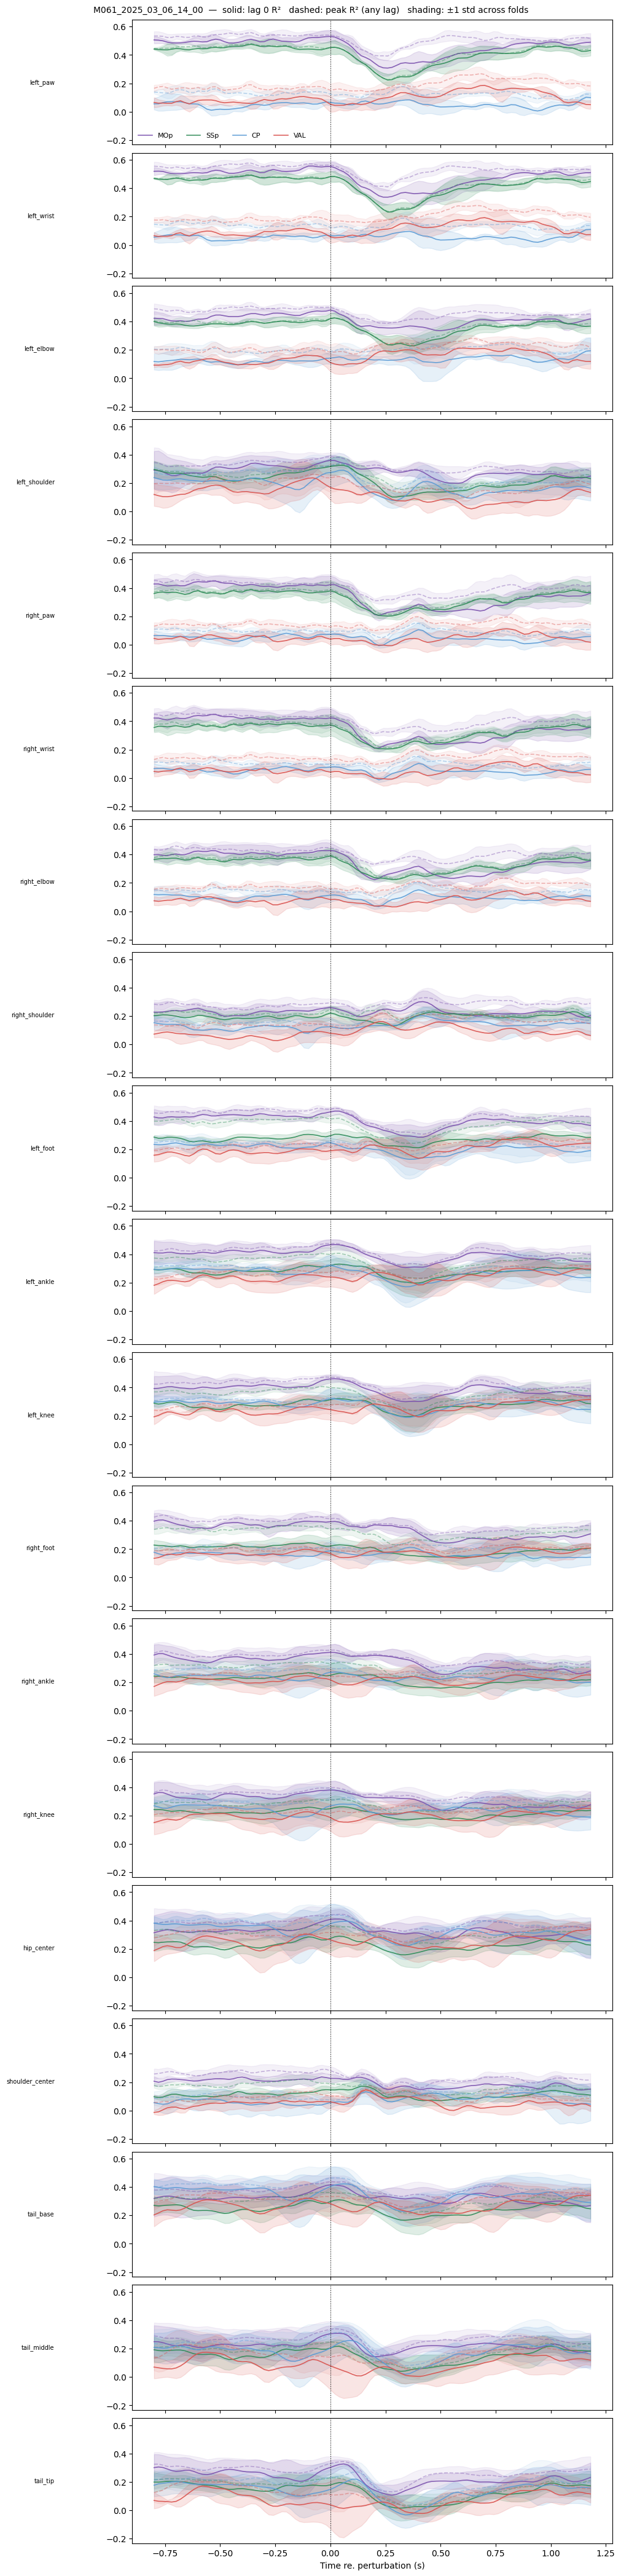

Keypoints: 19  |  Areas: ['MOp', 'SSp', 'CP', 'VAL']


In [16]:

# ── R² at lag 0 + peak R² (any lag) over time — rows = keypoints ─────────────
AREAS_PLOT  = [a for a in ['MOp', 'SSp', 'CP', 'VAL'] if a in session_data]
AREA_COLORS = {'MOp': '#7B52AE', 'SSp': '#2E8B57', 'CP': '#5B9BD5', 'VAL': '#D9534F'}

n_kp = len(kp_order)
fig, axes = plt.subplots(n_kp, 1, figsize=(10, 2.2 * n_kp),
                         sharex=True, sharey=True, constrained_layout=True)

for row, kp in enumerate(kp_order):
    ax = axes[row]
    for area in AREAS_PLOT:
        col     = AREA_COLORS[area]
        r2_data = np.array([session_data[area][kp][ti] for ti in all_t])  # (n_t, n_lags, n_folds)

        # lag 0
        r2_lag0_mean = r2_data[:, lag0_idx, :].mean(-1)   # (n_t,)
        r2_lag0_std  = r2_data[:, lag0_idx, :].std(-1)    # (n_t,)

        # peak across lags (per fold, then average)
        r2_peak_mean = r2_data.max(axis=1).mean(-1)       # (n_t,)
        r2_peak_std  = r2_data.max(axis=1).std(-1)        # (n_t,)

        label = area if row == 0 else None
        ax.plot(all_t, r2_lag0_mean, color=col, lw=1.2, alpha=0.9, label=label)
        ax.fill_between(all_t, r2_lag0_mean - r2_lag0_std, r2_lag0_mean + r2_lag0_std,
                        color=col, alpha=0.15)

        ax.plot(all_t, r2_peak_mean, color=col, lw=1.2, alpha=0.4, ls='--')
        ax.fill_between(all_t, r2_peak_mean - r2_peak_std, r2_peak_mean + r2_peak_std,
                        color=col, alpha=0.08)

    ax.axvline(0, color='k', lw=0.8, ls=':')
    ax.set_ylabel(kp, fontsize=7, rotation=0, ha='right', va='center', labelpad=60)

axes[-1].set_xlabel('Time re. perturbation (s)')
axes[0].legend(fontsize=8, frameon=False, ncol=len(AREAS_PLOT))
fig.suptitle(f'{SESSION}  —  solid: lag 0 R²   dashed: peak R² (any lag)   shading: ±1 std across folds',
             fontsize=10)
plt.show()

print(f"Keypoints: {len(kp_order)}  |  Areas: {AREAS_PLOT}")


  M062_2025_03_20_14_00 | VAL: not found, skipping
  M062_2025_03_21_14_00 | VAL: not found, skipping
  M086_2025_12_10_15_00 | VAL: not found, skipping
MOp: n=7 sessions | PCs per session: 25, 25, 25, 25, 25, 25, 25
SSp: n=7 sessions | PCs per session: 15, 15, 15, 15, 15, 15, 15
CP: n=7 sessions | PCs per session: 30, 30, 30, 30, 30, 30, 30
VAL: n=4 sessions | PCs per session: 50, 50, 50, 50


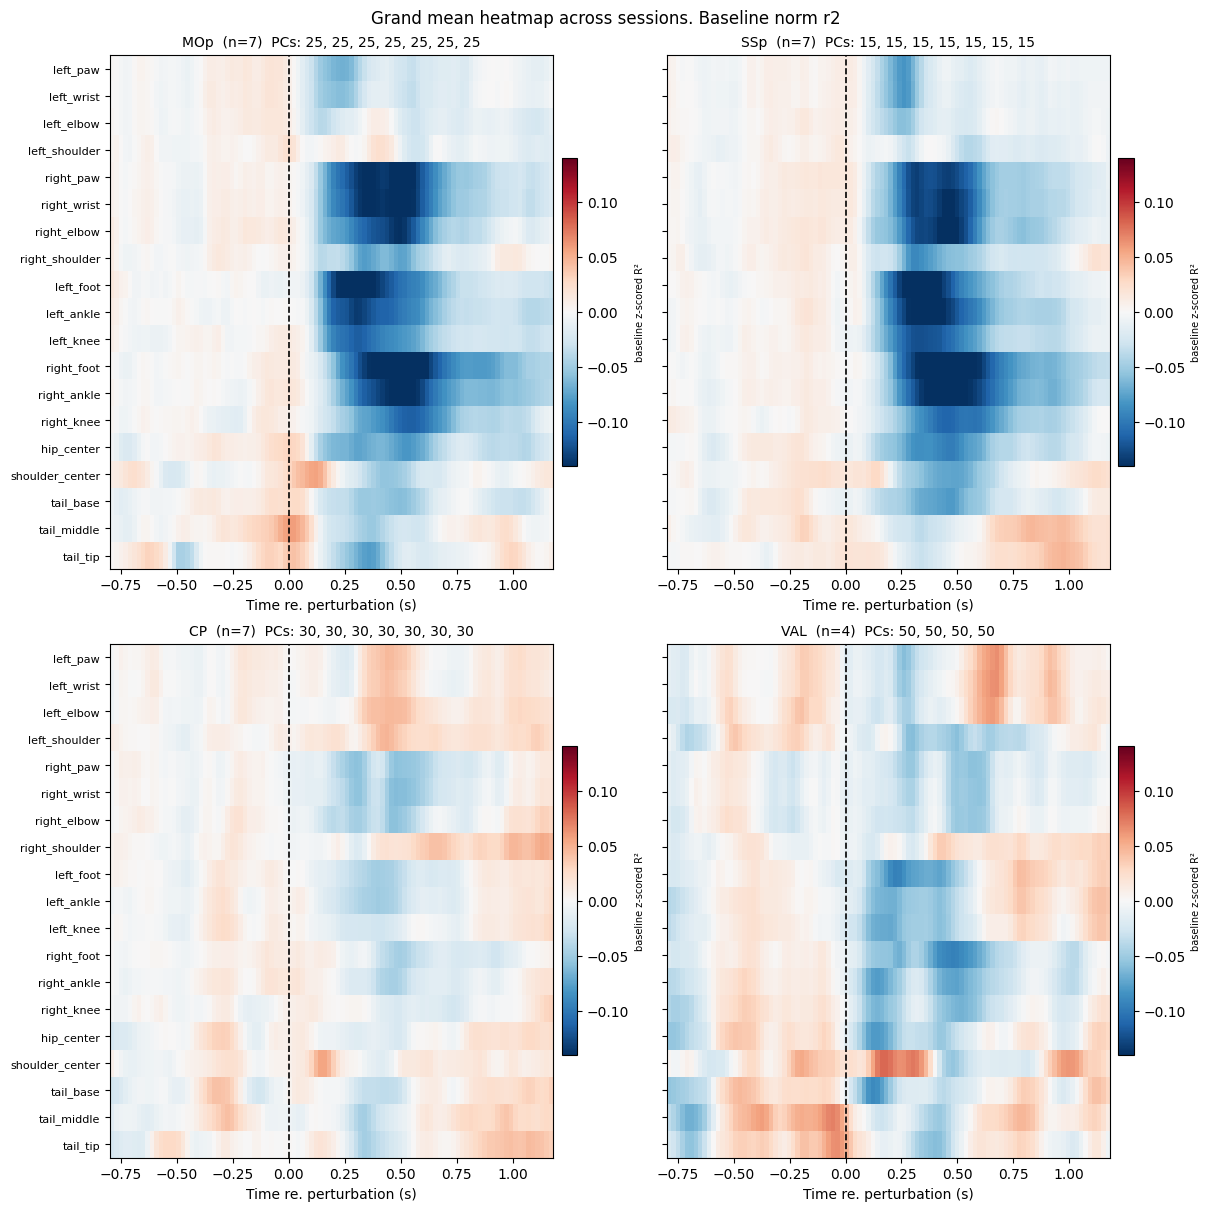

In [17]:

# ── Grand mean heatmap across sessions ───────────────────────────────────────
SESSIONS_ALL = [
    'M061_2025_03_04_10_00',
    'M061_2025_03_05_14_00',
    'M061_2025_03_06_14_00',
    'M062_2025_03_20_14_00',
    'M062_2025_03_21_14_00',
    'M078_2025_08_06_15_00',
    'M086_2025_12_10_15_00',
]

EXCLUDE_AREAS = {
    'M062_2025_03_20_14_00': ['VAL'],
    'M062_2025_03_21_14_00': ['VAL'],
    'M086_2025_12_10_15_00': ['VAL'],
}

AREAS_PLOT  = ['MOp', 'SSp', 'CP', 'VAL']

# accumulators: area -> list of (n_kp, n_t) matrices
mats_per_area  = {a: [] for a in AREAS_PLOT}
npcs_per_area  = {a: [] for a in AREAS_PLOT}   # track n_pcs per session

for sess in SESSIONS_ALL:
    sess_files = sorted(RESULTS_DIR.glob(f'lagged_dec_*_{sess}_npcs*.pkl'))
    if not sess_files:
        print(f"  No files found for {sess}, skipping")
        continue

    sess_data = {}
    for f in sess_files:
        area = f.name.split('_')[2]
        sess_data[area] = load_pkl(f)

    sess_all_t = np.array(sorted(sess_data[list(sess_data.keys())[0]][kp_order[0]].keys()))
    sess_bl    = (sess_all_t >= BASELINE_S[0]) & (sess_all_t < BASELINE_S[1])
    sess_lag0  = np.argmin(np.abs(sess_data[list(sess_data.keys())[0]]['_meta']['lags_s']))

    for area in AREAS_PLOT:
        if area not in sess_data:
            print(f"  {sess} | {area}: not found, skipping")
            continue
        if area in EXCLUDE_AREAS.get(sess, []):
            print(f"  {sess} | {area}: excluded")
            continue

        mat = []
        for kp in kp_order:
            if kp not in sess_data[area]:
                continue
            r2_data = np.array([sess_data[area][kp][ti].mean(-1) for ti in sess_all_t])
            r2_lag0 = r2_data[:, sess_lag0]
            bl_mean = r2_lag0[sess_bl].mean()
            bl_std  = r2_lag0[sess_bl].std() + 1e-8
            mat.append((r2_lag0 - bl_mean))#/ bl_std)

        if mat:
            mats_per_area[area].append(np.array(mat))
            npcs_per_area[area].append(sess_data[area]['_meta']['n_pcs'])

# ── plot grand mean ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharey=True, constrained_layout=True)
axes_flat = axes.flatten()

for ax, area in zip(axes_flat, AREAS_PLOT):
    stack = mats_per_area[area]
    if not stack:
        ax.set_title(f'{area} (no data)')
        continue

    grand_mean = np.mean(stack, axis=0)
    n_sess     = len(stack)
    pcs_str    = ', '.join(str(n) for n in npcs_per_area[area])

    vmax = np.percentile(np.abs(grand_mean), 95)
    im = ax.imshow(grand_mean, aspect='auto', cmap='RdBu_r',
                   vmin=-0.14, vmax=0.14,
                   extent=[sess_all_t[0], sess_all_t[-1], len(kp_order) - 0.5, -0.5])

    ax.axvline(0, color='k', lw=1.2, ls='--')
    ax.set_xlabel('Time re. perturbation (s)')
    ax.set_title(f'{area}  (n={n_sess})  PCs: {pcs_str}', fontsize=10)
    ax.set_yticks(range(len(kp_order)))
    ax.set_yticklabels(kp_order, fontsize=8)

    cb = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
    cb.set_label('baseline z-scored R²', fontsize=7)

    print(f"{area}: n={n_sess} sessions | PCs per session: {pcs_str}")

for ax in axes_flat[len(AREAS_PLOT):]:
    ax.set_visible(False)

fig.suptitle('Grand mean heatmap across sessions. Baseline norm r2', fontsize=12)
plt.show()


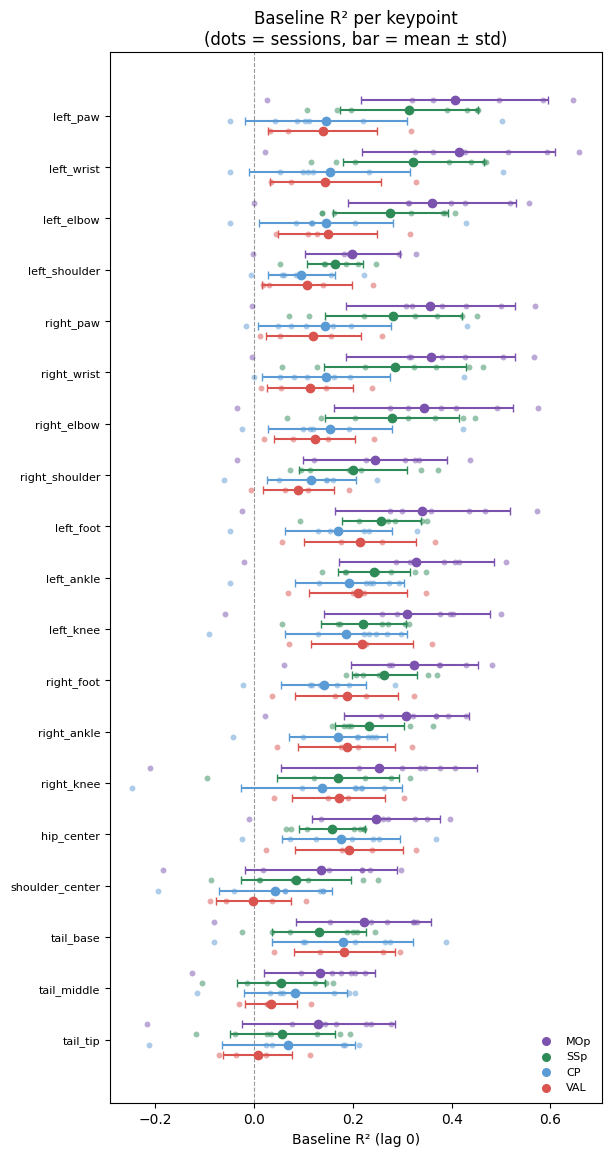

MOp: mean across keypoints = 0.285
SSp: mean across keypoints = 0.210
CP: mean across keypoints = 0.139
VAL: mean across keypoints = 0.136


In [18]:

# ── Baseline R² per keypoint × area — dots = sessions, errorbar = across sessions ──
# Y axis: keypoints (kp_order), X axis: raw R² at lag 0 during baseline window
AREAS_PLOT  = ['MOp', 'SSp', 'CP', 'VAL']
AREA_COLORS = {'MOp': '#7B52AE', 'SSp': '#2E8B57', 'CP': '#5B9BD5', 'VAL': '#D9534F'}
AREA_OFFSET = {'MOp': -0.3, 'SSp': -0.1, 'CP': 0.1, 'VAL': 0.3}  # y jitter per area

# r2_store[area][kp] = list of scalars (one per session)
r2_store = {a: {kp: [] for kp in kp_order} for a in AREAS_PLOT}

for sess in SESSIONS_ALL:
    sess_files = sorted(RESULTS_DIR.glob(f'lagged_dec_*_{sess}_npcs*.pkl'))
    if not sess_files:
        continue

    sess_data = {}
    for f in sess_files:
        area = f.name.split('_')[2]
        sess_data[area] = load_pkl(f)

    sess_all_t = np.array(sorted(sess_data[list(sess_data.keys())[0]][kp_order[0]].keys()))
    sess_bl    = (sess_all_t >= BASELINE_S[0]) & (sess_all_t < BASELINE_S[1])
    sess_lag0  = np.argmin(np.abs(sess_data[list(sess_data.keys())[0]]['_meta']['lags_s']))

    for area in AREAS_PLOT:
        if area not in sess_data or area in EXCLUDE_AREAS.get(sess, []):
            continue
        for kp in kp_order:
            if kp not in sess_data[area]:
                continue
            r2_data = np.array([sess_data[area][kp][ti].mean(-1) for ti in sess_all_t])
            r2_lag0 = r2_data[:, sess_lag0]
            r2_store[area][kp].append(r2_lag0[sess_bl].mean())

# ── plot ──────────────────────────────────────────────────────────────────────
n_kp = len(kp_order)
fig, ax = plt.subplots(figsize=(6, 0.55 * n_kp + 1), constrained_layout=True)

for ki, kp in enumerate(kp_order):
    for area in AREAS_PLOT:
        vals = np.array(r2_store[area][kp])
        if len(vals) == 0:
            continue
        col = AREA_COLORS[area]
        y   = ki + AREA_OFFSET[area]

        # individual session dots
        ax.scatter(vals, np.full(len(vals), y), color=col, s=18, alpha=0.5,
                   linewidths=0, zorder=2)

        # mean ± std across sessions
        ax.errorbar(vals.mean(), y, xerr=vals.std(),
                    fmt='o', color=col, markersize=6, capsize=3,
                    elinewidth=1.5, zorder=3)

ax.set_yticks(range(n_kp))
ax.set_yticklabels(kp_order, fontsize=8)
ax.set_xlabel('Baseline R² (lag 0)')
ax.axvline(0, color='k', lw=0.8, ls='--', alpha=0.4)
ax.invert_yaxis()

# legend
for area in AREAS_PLOT:
    ax.scatter([], [], color=AREA_COLORS[area], s=30, label=area)
ax.legend(fontsize=8, frameon=False, loc='lower right')

ax.set_title('Baseline R² per keypoint\n(dots = sessions, bar = mean ± std)')
plt.show()

for area in AREAS_PLOT:
    means = [np.mean(r2_store[area][kp]) for kp in kp_order if r2_store[area][kp]]
    print(f"{area}: mean across keypoints = {np.mean(means):.3f}")


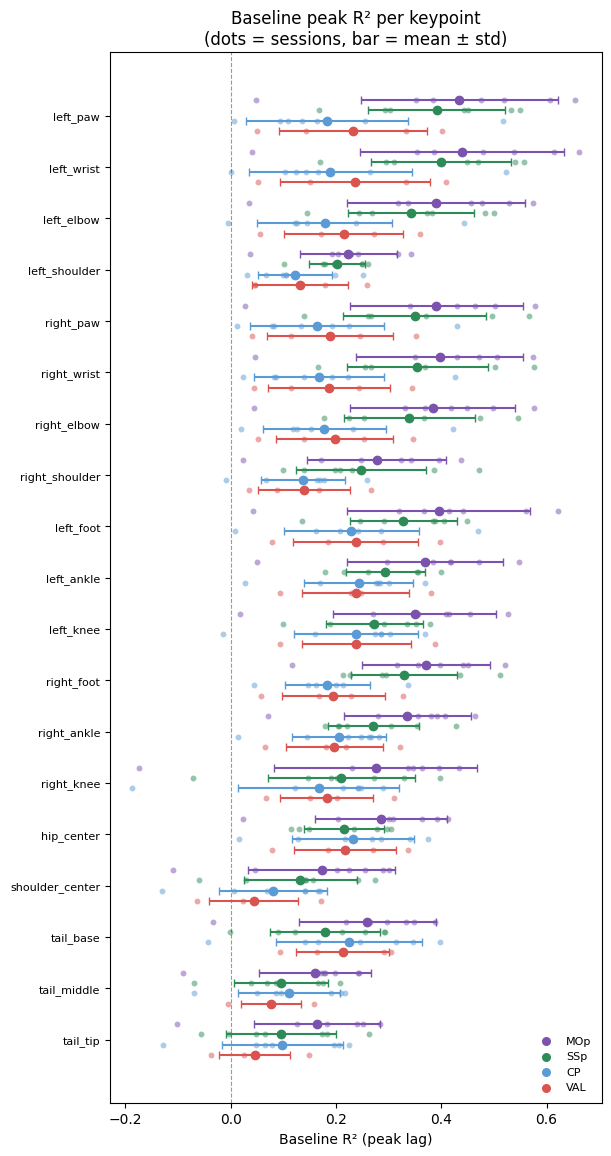

MOp: mean across keypoints = 0.320
SSp: mean across keypoints = 0.266
CP: mean across keypoints = 0.175
VAL: mean across keypoints = 0.180


In [19]:

# ── Baseline peak R² (any lag) per keypoint × area ───────────────────────────
r2_store_peak = {a: {kp: [] for kp in kp_order} for a in AREAS_PLOT}

for sess in SESSIONS_ALL:
    sess_files = sorted(RESULTS_DIR.glob(f'lagged_dec_*_{sess}_npcs*.pkl'))
    if not sess_files:
        continue

    sess_data = {}
    for f in sess_files:
        area = f.name.split('_')[2]
        sess_data[area] = load_pkl(f)

    sess_all_t = np.array(sorted(sess_data[list(sess_data.keys())[0]][kp_order[0]].keys()))
    sess_bl    = (sess_all_t >= BASELINE_S[0]) & (sess_all_t < BASELINE_S[1])

    for area in AREAS_PLOT:
        if area not in sess_data or area in EXCLUDE_AREAS.get(sess, []):
            continue
        for kp in kp_order:
            if kp not in sess_data[area]:
                continue
            r2_data = np.array([sess_data[area][kp][ti].mean(-1) for ti in sess_all_t])  # (n_t, n_lags)
            r2_peak = r2_data.max(axis=1)  # (n_t,)
            r2_store_peak[area][kp].append(r2_peak[sess_bl].mean())

# ── plot ──────────────────────────────────────────────────────────────────────
n_kp = len(kp_order)
fig, ax = plt.subplots(figsize=(6, 0.55 * n_kp + 1), constrained_layout=True)

for ki, kp in enumerate(kp_order):
    for area in AREAS_PLOT:
        vals = np.array(r2_store_peak[area][kp])
        if len(vals) == 0:
            continue
        col = AREA_COLORS[area]
        y   = ki + AREA_OFFSET[area]

        ax.scatter(vals, np.full(len(vals), y), color=col, s=18, alpha=0.5,
                   linewidths=0, zorder=2)
        ax.errorbar(vals.mean(), y, xerr=vals.std(),
                    fmt='o', color=col, markersize=6, capsize=3,
                    elinewidth=1.5, zorder=3)

ax.set_yticks(range(n_kp))
ax.set_yticklabels(kp_order, fontsize=8)
ax.set_xlabel('Baseline R² (peak lag)')
ax.axvline(0, color='k', lw=0.8, ls='--', alpha=0.4)
ax.invert_yaxis()

for area in AREAS_PLOT:
    ax.scatter([], [], color=AREA_COLORS[area], s=30, label=area)
ax.legend(fontsize=8, frameon=False, loc='lower right')

ax.set_title('Baseline peak R² per keypoint\n(dots = sessions, bar = mean ± std)')
plt.show()

for area in AREAS_PLOT:
    means = [np.mean(r2_store_peak[area][kp]) for kp in kp_order if r2_store_peak[area][kp]]
    print(f"{area}: mean across keypoints = {np.mean(means):.3f}")


# Drift analysis

Session : M062_2025_03_20_14_00
Lag range: (-0.15, 0.15)  |  past bins: 15  future bins: 15
Areas loaded: ['CP', 'MOp', 'SSp']


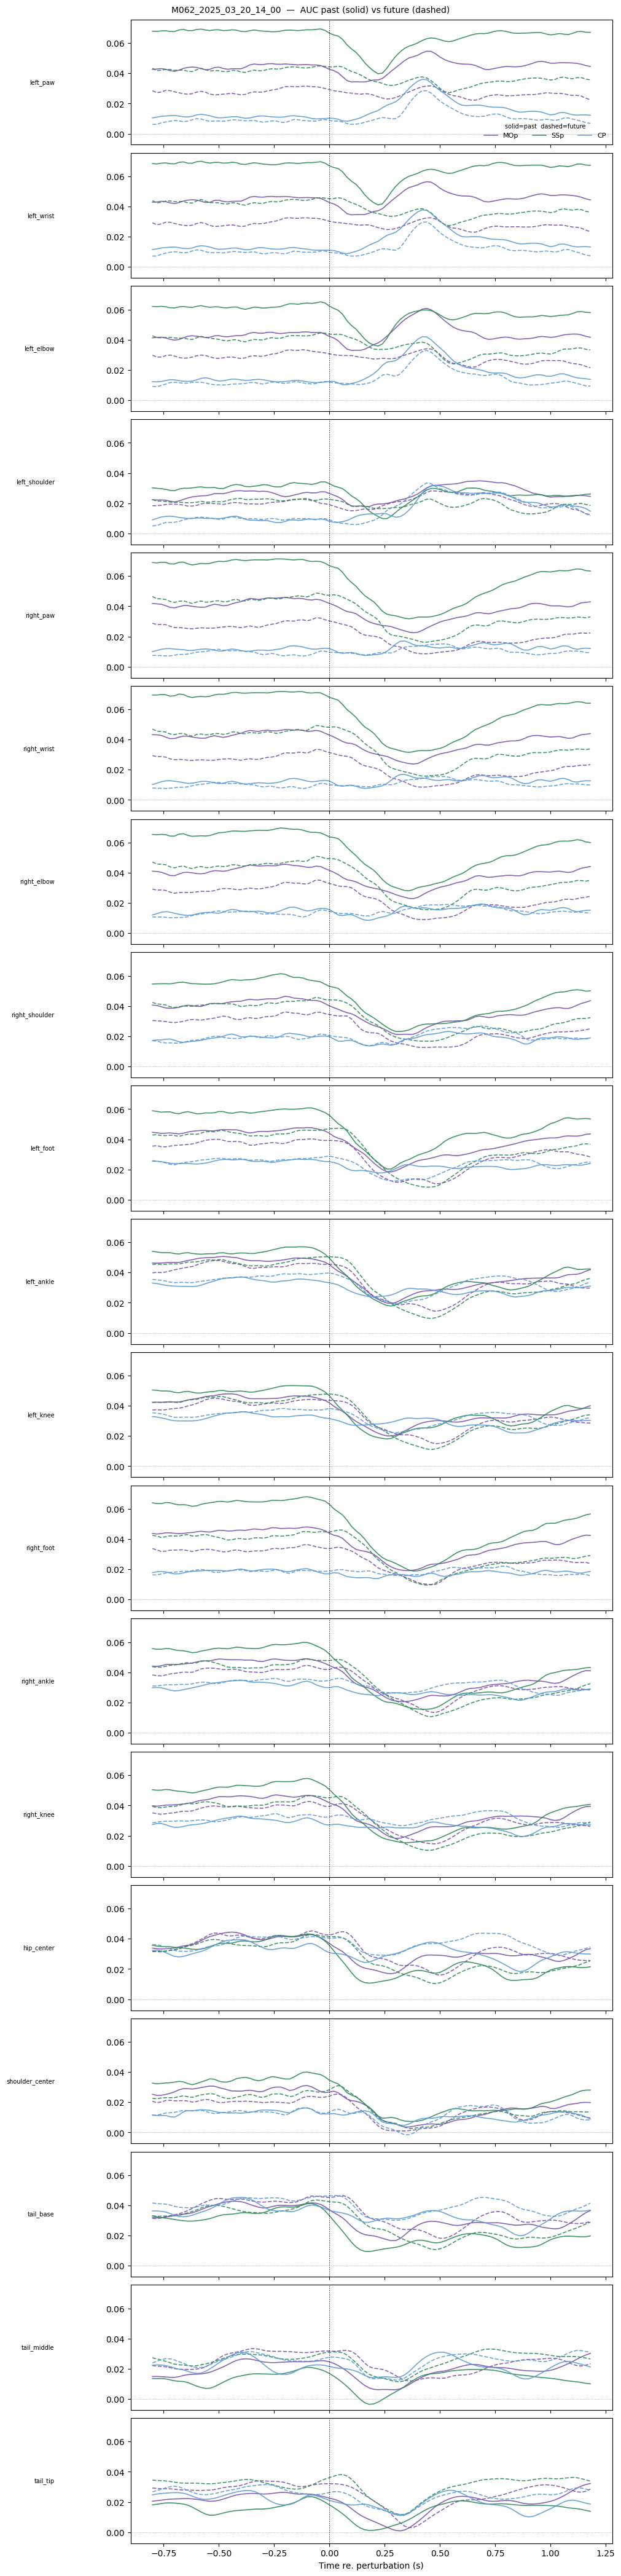

Keypoints: 19


In [22]:

# ── AUC past / future — session by session ────────────────────────────────────
# Parameters — edit these
AUC_SESSION = 'M062_2025_03_20_14_00'
LAG_RANGE   = (-0.15, 0.15)   # seconds, must be within the lag range of the pkl files

AREAS_PLOT  = ['MOp', 'SSp', 'CP', 'VAL']
AREA_COLORS = {'MOp': '#7B52AE', 'SSp': '#2E8B57', 'CP': '#5B9BD5', 'VAL': '#D9534F'}

# ── load session ──────────────────────────────────────────────────────────────
auc_sess_data = {}
for f in sorted(RESULTS_DIR.glob(f'lagged_dec_*_{AUC_SESSION}_npcs*.pkl')):
    area = f.name.split('_')[2]
    auc_sess_data[area] = load_pkl(f)

assert auc_sess_data, f"No files found for {AUC_SESSION}"
_lags_s  = auc_sess_data[list(auc_sess_data.keys())[0]]['_meta']['lags_s']
_all_t   = np.array(sorted(auc_sess_data[list(auc_sess_data.keys())[0]][kp_order[0]].keys()))

lag_mask    = (_lags_s >= LAG_RANGE[0]) & (_lags_s <= LAG_RANGE[1])
past_mask   = _lags_s[lag_mask] < 0
future_mask = _lags_s[lag_mask] > 0
lags_masked = _lags_s[lag_mask]

print(f"Session : {AUC_SESSION}")
print(f"Lag range: {LAG_RANGE}  |  past bins: {past_mask.sum()}  future bins: {future_mask.sum()}")
print(f"Areas loaded: {list(auc_sess_data.keys())}")

def compute_auc_timeseries(data, kp):
    """Returns (auc_past, auc_future) each shape (n_t,)"""
    auc_past, auc_future = [], []
    for ti in _all_t:
        curve = data[kp][ti].mean(-1)[lag_mask]   # mean across folds, then mask lags
        auc_past.append(np.trapz(curve[past_mask],   lags_masked[past_mask]))
        auc_future.append(np.trapz(curve[future_mask], lags_masked[future_mask]))
    return np.array(auc_past), np.array(auc_future)

# ── plot: rows = keypoints, 8 lines per subplot (4 areas × past/future) ───────
n_kp = len(kp_order)
fig, axes = plt.subplots(n_kp, 1, figsize=(10, 2.2 * n_kp),
                         sharex=True, sharey=True, constrained_layout=True)

for row, kp in enumerate(kp_order):
    ax = axes[row]
    for area in AREAS_PLOT:
        if area not in auc_sess_data:
            continue
        col = AREA_COLORS[area]
        auc_p, auc_f = compute_auc_timeseries(auc_sess_data[area], kp)
        label_p = area if row == 0 else None
        ax.plot(_all_t, auc_p, color=col, lw=1.2, alpha=0.9, label=label_p)
        ax.plot(_all_t, auc_f, color=col, lw=1.2, alpha=0.9, ls='--')

    ax.axvline(0, color='k', lw=0.8, ls=':')
    ax.axhline(0, color='gray', lw=0.5, ls=':')
    ax.set_ylabel(kp, fontsize=7, rotation=0, ha='right', va='center', labelpad=60)

axes[-1].set_xlabel('Time re. perturbation (s)')
axes[0].legend(fontsize=8, frameon=False, ncol=len(AREAS_PLOT),
               title='solid=past  dashed=future', title_fontsize=7)
fig.suptitle(f'{AUC_SESSION}  —  AUC past (solid) vs future (dashed)', fontsize=10)
plt.show()

print(f"Keypoints: {len(kp_order)}")


MOp: n=7  grand mean shape (19, 100)  vmax=3.86
SSp: n=7  grand mean shape (19, 100)  vmax=4.95
CP: n=7  grand mean shape (19, 100)  vmax=2.39
VAL: n=4  grand mean shape (19, 100)  vmax=4.03


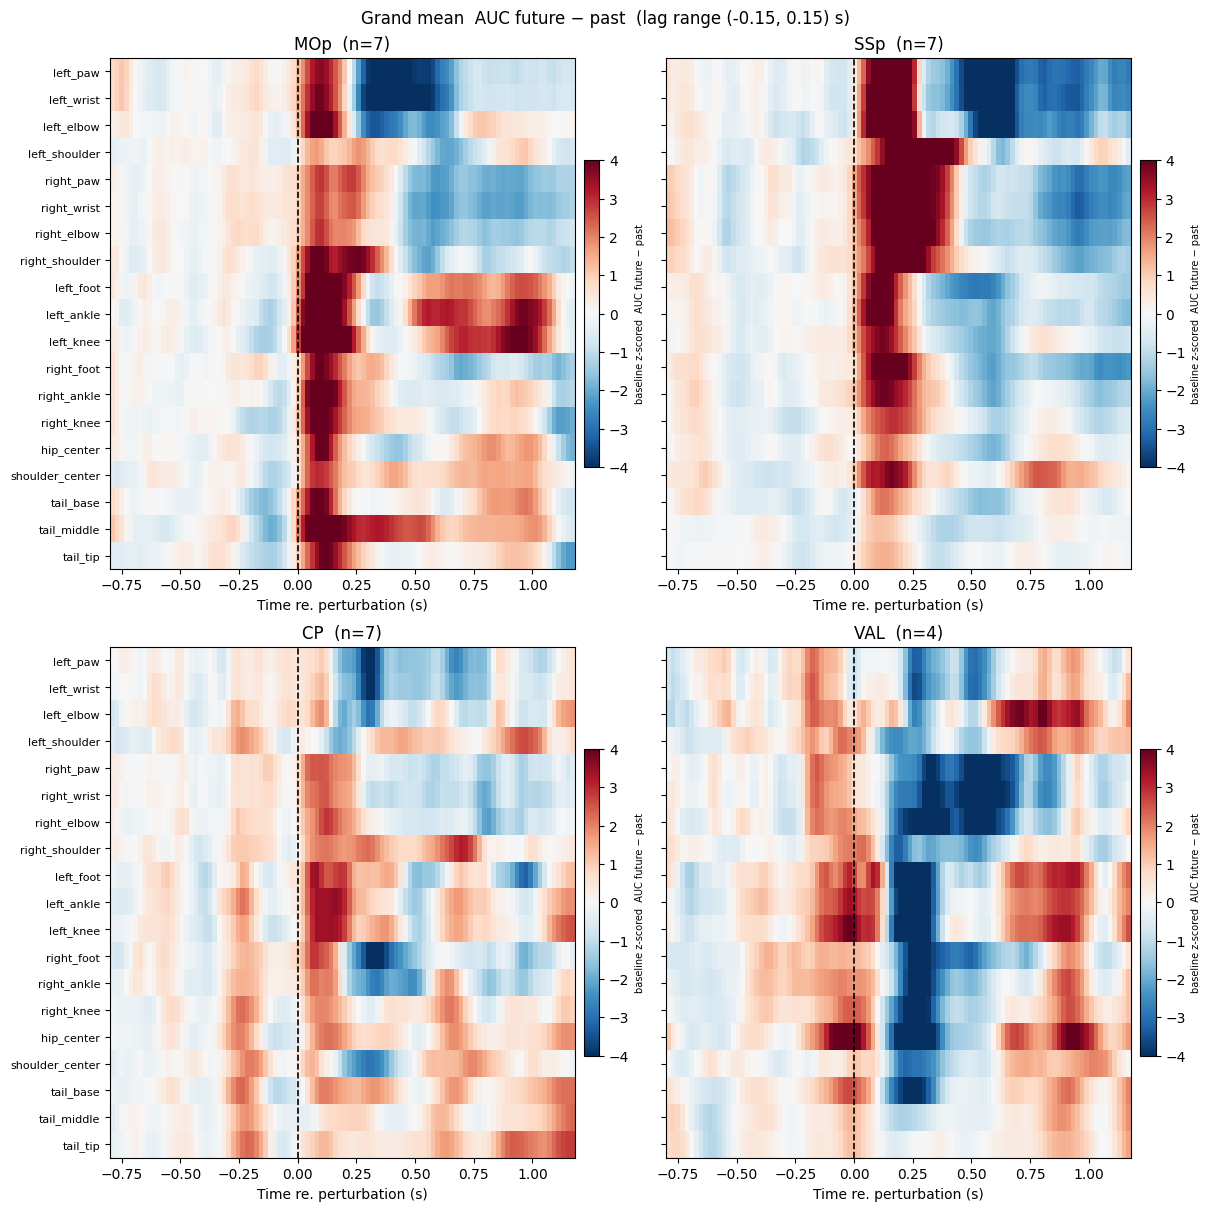

In [24]:

# ── Grand mean heatmap: AUC future − past, across sessions ───────────────────
auc_diff_per_area = {a: [] for a in AREAS_PLOT}  # area -> list of (n_kp, n_t)

for sess in SESSIONS_ALL:
    sess_files = sorted(RESULTS_DIR.glob(f'lagged_dec_*_{sess}_npcs*.pkl'))
    if not sess_files:
        continue

    sess_data = {}
    for f in sess_files:
        area = f.name.split('_')[2]
        sess_data[area] = load_pkl(f)

    s_lags_s  = sess_data[list(sess_data.keys())[0]]['_meta']['lags_s']
    s_all_t   = np.array(sorted(sess_data[list(sess_data.keys())[0]][kp_order[0]].keys()))
    s_bl      = (s_all_t >= BASELINE_S[0]) & (s_all_t < BASELINE_S[1])

    s_lag_mask    = (s_lags_s >= LAG_RANGE[0]) & (s_lags_s <= LAG_RANGE[1])
    s_past_mask   = s_lags_s[s_lag_mask] < 0
    s_future_mask = s_lags_s[s_lag_mask] > 0
    s_lags_masked = s_lags_s[s_lag_mask]

    for area in AREAS_PLOT:
        if area not in sess_data or area in EXCLUDE_AREAS.get(sess, []):
            continue

        mat = []
        for kp in kp_order:
            if kp not in sess_data[area]:
                continue
            auc_p, auc_f = [], []
            for ti in s_all_t:
                curve = sess_data[area][kp][ti].mean(-1)[s_lag_mask]
                auc_p.append(np.trapz(curve[s_past_mask],   s_lags_masked[s_past_mask]))
                auc_f.append(np.trapz(curve[s_future_mask], s_lags_masked[s_future_mask]))
            diff = np.array(auc_f) - np.array(auc_p)

            # baseline z-score
            bl_mean = diff[s_bl].mean()
            bl_std  = diff[s_bl].std() + 1e-8
            mat.append((diff - bl_mean) / bl_std)

        if mat:
            auc_diff_per_area[area].append(np.array(mat))

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 12), sharey=True, constrained_layout=True)
axes_flat = axes.flatten()

for ax, area in zip(axes_flat, AREAS_PLOT):
    stack = auc_diff_per_area[area]
    if not stack:
        ax.set_title(f'{area} (no data)')
        continue

    grand_mean = np.mean(stack, axis=0)   # (n_kp, n_t)
    n_sess     = len(stack)

    vmax = np.percentile(np.abs(grand_mean), 95)
    im = ax.imshow(grand_mean, aspect='auto', cmap='RdBu_r',
                   vmin=-4, vmax=4,
                   extent=[s_all_t[0], s_all_t[-1], len(kp_order) - 0.5, -0.5])

    ax.axvline(0, color='k', lw=1.2, ls='--')
    ax.set_xlabel('Time re. perturbation (s)')
    ax.set_title(f'{area}  (n={n_sess})', fontsize=12)
    ax.set_yticks(range(len(kp_order)))
    ax.set_yticklabels(kp_order, fontsize=8)

    cb = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
    cb.set_label('baseline z-scored  AUC future − past', fontsize=7)

    print(f"{area}: n={n_sess}  grand mean shape {grand_mean.shape}  vmax={vmax:.2f}")

for ax in axes_flat[len(AREAS_PLOT):]:
    ax.set_visible(False)

fig.suptitle(f'Grand mean  AUC future − past  (lag range {LAG_RANGE} s)', fontsize=12)
plt.show()


In [ ]:
ALL_SESSIONS = [
    # "M061_2025_03_04_10_00",
    # "M061_2025_03_05_14_00",
    # "M061_2025_03_06_14_00",
    # "M063_2025_03_13_14_00",
    # "M063_2025_03_14_15_30",
    # "M062_2025_03_20_14_00",
    # "M062_2025_03_21_14_00",
    # "M078_2025_08_06_15_00",
    # "M086_2025_12_10_15_00",
    # "M103_2026_02_18_15_30",
    # "M103_2026_02_19_15_30",
    # "M106_2026_02_25_15_00",
    # "M106_2026_02_26_16_00",
]

In [145]:
drift_files

[PosixPath('/data/equake_results/lagged_kin_dec_no_smoothing/lagged_dec_MOp_M061_2025_03_05_14_00_npcs100.pkl'),
 PosixPath('/data/equake_results/lagged_kin_dec_no_smoothing/lagged_dec_MOp_M061_2025_03_05_14_00_npcs25.pkl')]

Session: M078_2025_08_06_15_00  |  Area: MOp  |  KP: left_elbow
Lag res: 10.0 ms  |  helper t = 0.240 s  |  peak = -0.72 ms


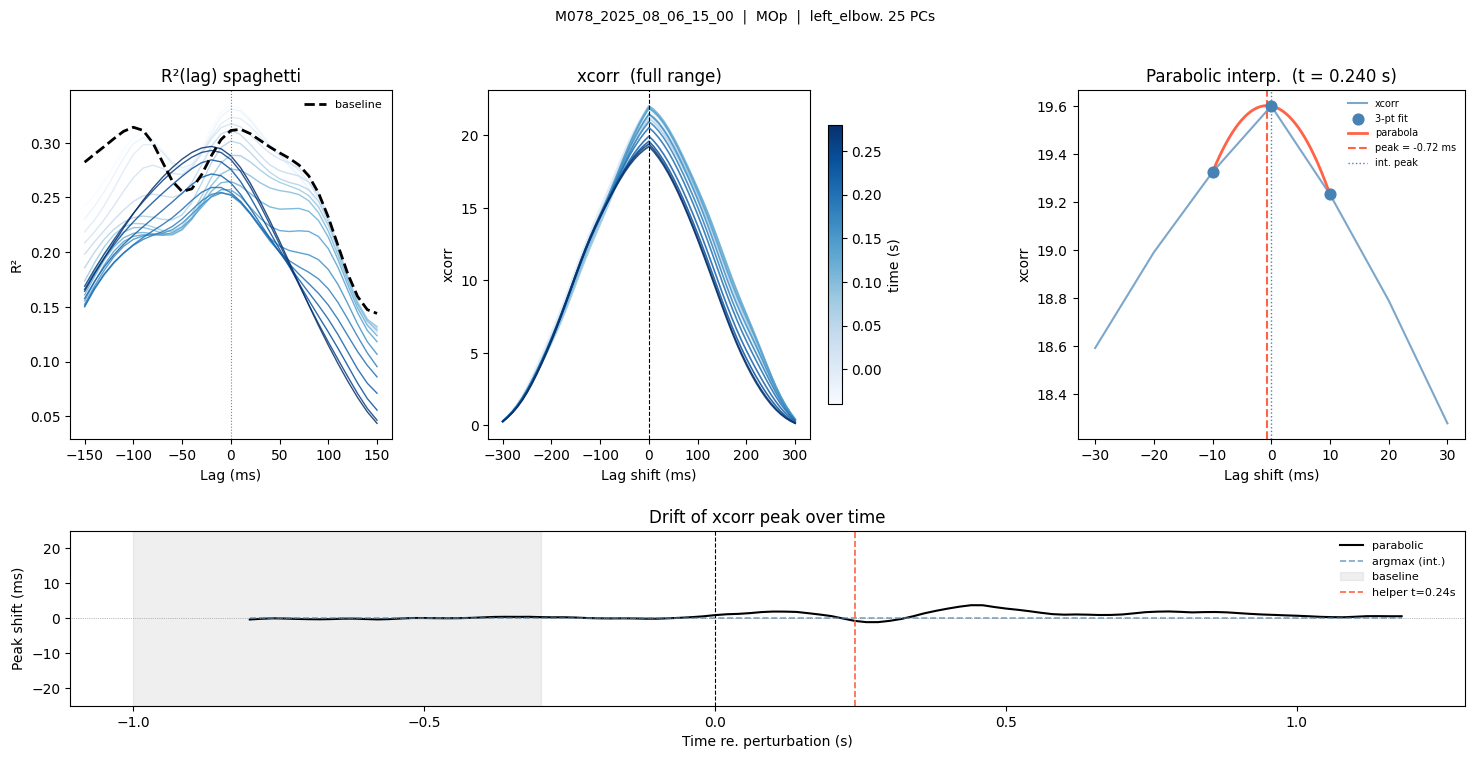


Baseline mean drift : 0.00 ms
Peak post-perturb   : 3.76 ms at t=0.44 s


In [196]:
 # ── Drift analysis: spaghetti + xcorr + parabolic helper + drift ─────────────
# Parameters — edit these
DRIFT_SESSION  = 'M078_2025_08_06_15_00'
DRIFT_AREA     = 'MOp'
DRIFT_KP       = 'left_elbow'
DRIFT_T_RANGE  = (-0.05, 0.3)   # spaghetti / xcorr display window (s)
DRIFT_T_HELPER = 0.25           # time point for parabola helper (None = peak drift)

from scipy.signal import correlate

def _get_xcorr(curve, baseline):
    c = curve    / (curve.max()    + 1e-12)
    b = baseline / (baseline.max() + 1e-12)
    return correlate(c, b, mode='full')

def _compute_drift(curve, baseline, lags):
    """Parabolic interpolation around xcorr peak → sub-sample lag shift in ms."""
    xc   = _get_xcorr(curve, baseline)
    step = lags[1] - lags[0]
    pk   = xc.argmax()
    if 0 < pk < len(xc) - 1:
        y0, y1, y2 = xc[pk - 1], xc[pk], xc[pk + 1]
        delta = 0.5 * (y0 - y2) / (y0 - 2 * y1 + y2 + 1e-12)
        return (pk + delta) * step - (len(lags) - 1) * step
    return (pk - (len(lags) - 1)) * step

# ── load ──────────────────────────────────────────────────────────────────────
drift_files = sorted(RESULTS_DIR.glob(f'lagged_dec_{DRIFT_AREA}_{DRIFT_SESSION}_npcs*.pkl'))
assert drift_files, f"No file found for {DRIFT_AREA} / {DRIFT_SESSION}"
drift_data = load_pkl(drift_files[0])

d_lags_s  = drift_data['_meta']['lags_s']
d_lags_ms = d_lags_s * 1000
d_all_t   = np.array(sorted(drift_data[DRIFT_KP].keys()))
d_bl      = (d_all_t >= BASELINE_S[0]) & (d_all_t < BASELINE_S[1])
d_t_mask  = (d_all_t >= DRIFT_T_RANGE[0]) & (d_all_t <= DRIFT_T_RANGE[1])

bl_curves = np.array([drift_data[DRIFT_KP][t].mean(-1) for t in d_all_t[d_bl]])
bl_ref    = bl_curves.mean(0)

n_lags   = len(d_lags_s)
dt_ms    = d_lags_ms[1] - d_lags_ms[0]
shift_ms = np.arange(-(n_lags - 1), n_lags) * dt_ms

# parabolic sub-sample drift
drift_ms = np.array([_compute_drift(drift_data[DRIFT_KP][t].mean(-1), bl_ref, d_lags_ms)
                     for t in d_all_t])

# integer argmax drift (no sub-sample correction)
drift_int_ms = np.array([
    _get_xcorr(drift_data[DRIFT_KP][t].mean(-1), bl_ref).argmax() * dt_ms - (n_lags - 1) * dt_ms
    for t in d_all_t
])

t_plot = d_all_t[d_t_mask]
xcorrs = np.array([_get_xcorr(drift_data[DRIFT_KP][t].mean(-1), bl_ref) for t in t_plot])

# ── pick helper time point ────────────────────────────────────────────────────
if DRIFT_T_HELPER is None:
    _post    = d_all_t > 0
    helper_t = d_all_t[_post][np.abs(drift_ms[_post]).argmax()]
else:
    helper_t = d_all_t[np.argmin(np.abs(d_all_t - DRIFT_T_HELPER))]

xc_helper = _get_xcorr(drift_data[DRIFT_KP][helper_t].mean(-1), bl_ref)
pk        = xc_helper.argmax()
y0, y1, y2 = xc_helper[pk - 1], xc_helper[pk], xc_helper[pk + 1]
delta     = 0.5 * (y0 - y2) / (y0 - 2 * y1 + y2 + 1e-12)
peak_sub  = (pk + delta) * dt_ms - (n_lags - 1) * dt_ms

_x_pts  = np.array([pk - 1, pk, pk + 1]) * dt_ms - (n_lags - 1) * dt_ms
_x_fine = np.linspace(_x_pts[0], _x_pts[2], 200)
_A = np.vstack([_x_pts**2, _x_pts, np.ones(3)]).T
_a, _b, _c = np.linalg.solve(_A, np.array([y0, y1, y2]))
_parab = _a * _x_fine**2 + _b * _x_fine + _c

print(f"Session: {DRIFT_SESSION}  |  Area: {DRIFT_AREA}  |  KP: {DRIFT_KP}")
print(f"Lag res: {dt_ms:.1f} ms  |  helper t = {helper_t:.3f} s  |  peak = {peak_sub:.2f} ms")

# ── plot ──────────────────────────────────────────────────────────────────────
cmap   = plt.cm.Blues
t_norm = mpl.colors.Normalize(vmin=t_plot.min(), vmax=t_plot.max())

fig = plt.figure(figsize=(18, 8))
gs  = fig.add_gridspec(2, 3, height_ratios=[2, 1], hspace=0.35, wspace=0.3)
ax_sp   = fig.add_subplot(gs[0, 0])
ax_xc   = fig.add_subplot(gs[0, 1])
ax_par  = fig.add_subplot(gs[0, 2])
ax_drft = fig.add_subplot(gs[1, :])

# ── spaghetti ────────────────────────────────────────────────────────────────
for t_s in t_plot:
    ax_sp.plot(d_lags_ms, drift_data[DRIFT_KP][t_s].mean(-1),
               color=cmap(t_norm(t_s)), lw=1.0, alpha=0.85)
ax_sp.plot(d_lags_ms, bl_ref, color='k', lw=2, ls='--', zorder=10, label='baseline')
ax_sp.axvline(0, color='gray', lw=0.8, ls=':')
ax_sp.set_xlabel('Lag (ms)')
ax_sp.set_ylabel('R²')
ax_sp.set_title('R²(lag) spaghetti')
ax_sp.legend(fontsize=8, frameon=False)

# ── xcorr (full range) ───────────────────────────────────────────────────────
for t_s, xc in zip(t_plot, xcorrs):
    ax_xc.plot(shift_ms, xc, color=cmap(t_norm(t_s)), lw=1.2, alpha=0.85)
ax_xc.axvline(0, color='k', lw=0.8, ls='--')
ax_xc.set_xlabel('Lag shift (ms)')
ax_xc.set_ylabel('xcorr')
ax_xc.set_title('xcorr  (full range)')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=t_norm)
sm.set_array([])
fig.colorbar(sm, ax=[ax_sp, ax_xc], shrink=0.8, pad=0.02, label='time (s)')
# ax_xc.set_xlim(-30, 30)
# ax_xc.set_ylim(15, 25)


# ── parabolic interpolation helper ───────────────────────────────────────────
_zoom = 3
_idx0, _idx1 = max(pk - _zoom, 0), min(pk + _zoom + 1, len(xc_helper))
ax_par.plot(shift_ms[_idx0:_idx1], xc_helper[_idx0:_idx1],
            color='steelblue', lw=1.5, alpha=0.7, label='xcorr')
ax_par.scatter(_x_pts, [y0, y1, y2],
               color='steelblue', s=60, zorder=5, label='3-pt fit')
ax_par.plot(_x_fine, _parab, color='tomato', lw=2, label='parabola')
ax_par.axvline(peak_sub, color='tomato', lw=1.5, ls='--', label=f'peak = {peak_sub:.2f} ms')
ax_par.axvline(pk * dt_ms - (n_lags - 1) * dt_ms,
               color='steelblue', lw=1.0, ls=':', label='int. peak')
ax_par.set_xlabel('Lag shift (ms)')
ax_par.set_ylabel('xcorr')
ax_par.set_title(f'Parabolic interp.  (t = {helper_t:.3f} s)')
ax_par.legend(fontsize=7, frameon=False)

# ── drift over time ───────────────────────────────────────────────────────────
ax_drft.plot(d_all_t, drift_ms,     color='k',        lw=1.5, label='parabolic')
ax_drft.plot(d_all_t, drift_int_ms, color='steelblue', lw=1.2, ls='--', alpha=0.7, label='argmax (int.)')
ax_drft.axvspan(BASELINE_S[0], BASELINE_S[1], color='gray', alpha=0.12, label='baseline')
ax_drft.axvline(0,        color='k',     lw=0.8, ls='--')
ax_drft.axhline(0,        color='gray',  lw=0.5, ls=':')
ax_drft.axvline(helper_t, color='tomato', lw=1.2, ls='--', label=f'helper t={helper_t:.2f}s')
ax_drft.set_xlabel('Time re. perturbation (s)')
ax_drft.set_ylabel('Peak shift (ms)')
ax_drft.set_title('Drift of xcorr peak over time')
ax_drft.legend(fontsize=8, frameon=False)
ax_drft.set_ylim(-25, 25)

fig.suptitle(f'{DRIFT_SESSION}  |  {DRIFT_AREA}  |  {DRIFT_KP}. 25 PCs', fontsize=10)
plt.show()

print(f"\nBaseline mean drift : {drift_ms[d_bl].mean():.2f} ms")
print(f"Peak post-perturb   : {drift_ms.max():.2f} ms at t={d_all_t[drift_ms.argmax()]:.2f} s")


In [123]:
SESSIONS_ALL = [
    "M061_2025_03_04_10_00",
    "M061_2025_03_05_14_00",
    "M061_2025_03_06_14_00",
    # "M063_2025_03_13_14_00",
    # "M063_2025_03_14_15_30",
    "M062_2025_03_20_14_00",
    "M062_2025_03_21_14_00",
    "M078_2025_08_06_15_00",
    # "M086_2025_12_10_15_00",
    # "M103_2026_02_18_15_30",
    # "M103_2026_02_19_15_30",
    # "M106_2026_02_25_15_00",
    # "M106_2026_02_26_16_00",
]

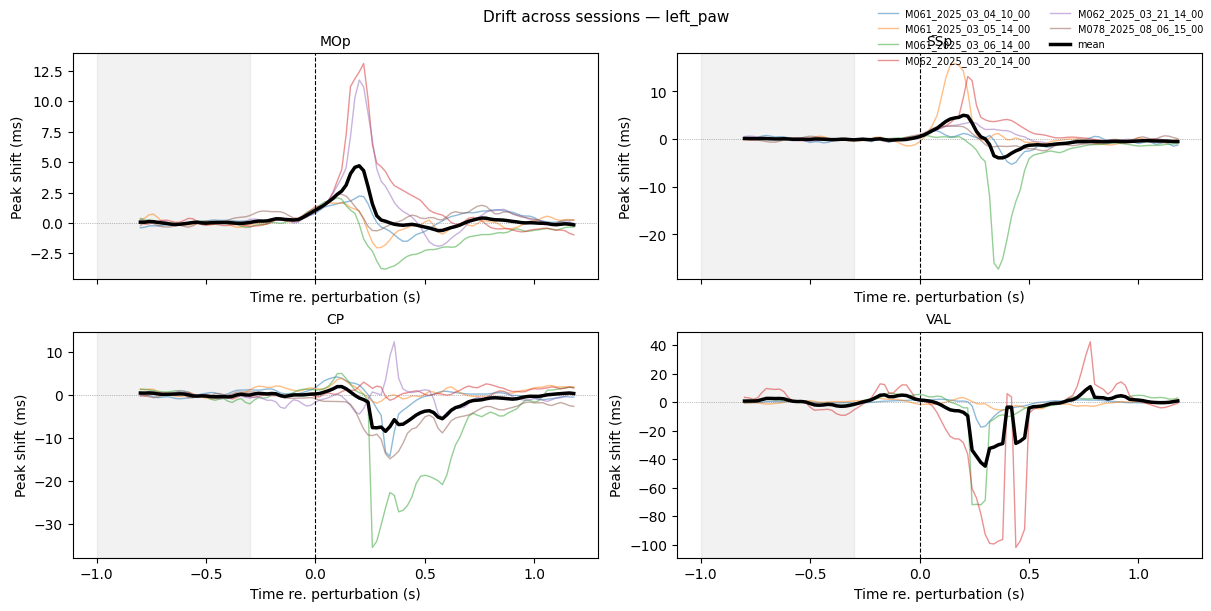

  left_paw: plotted


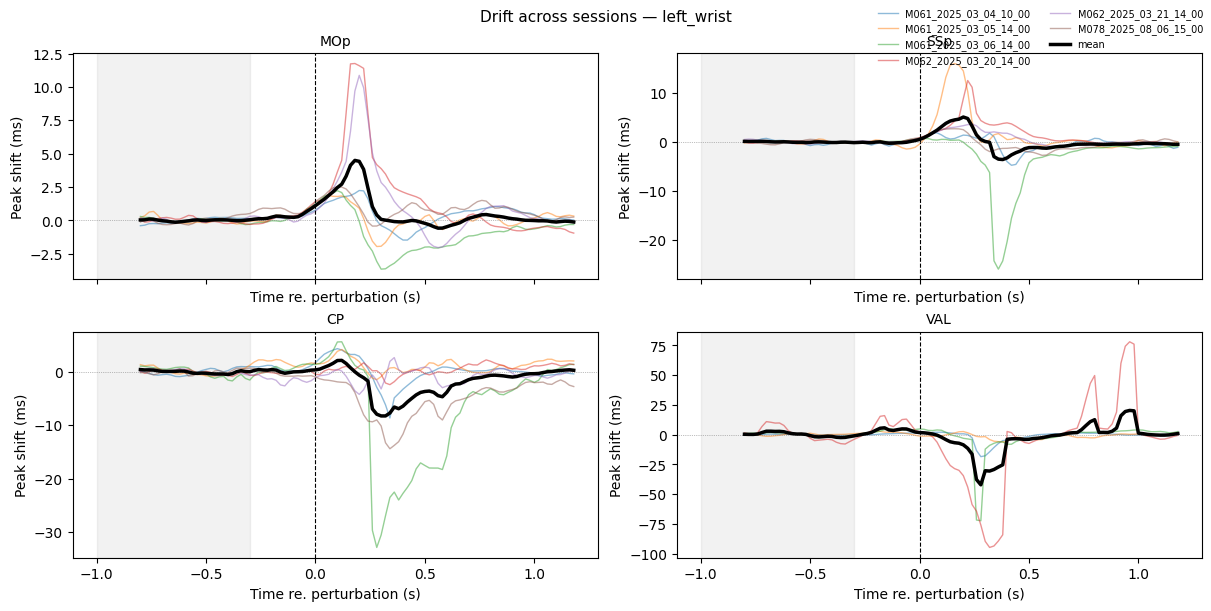

  left_wrist: plotted


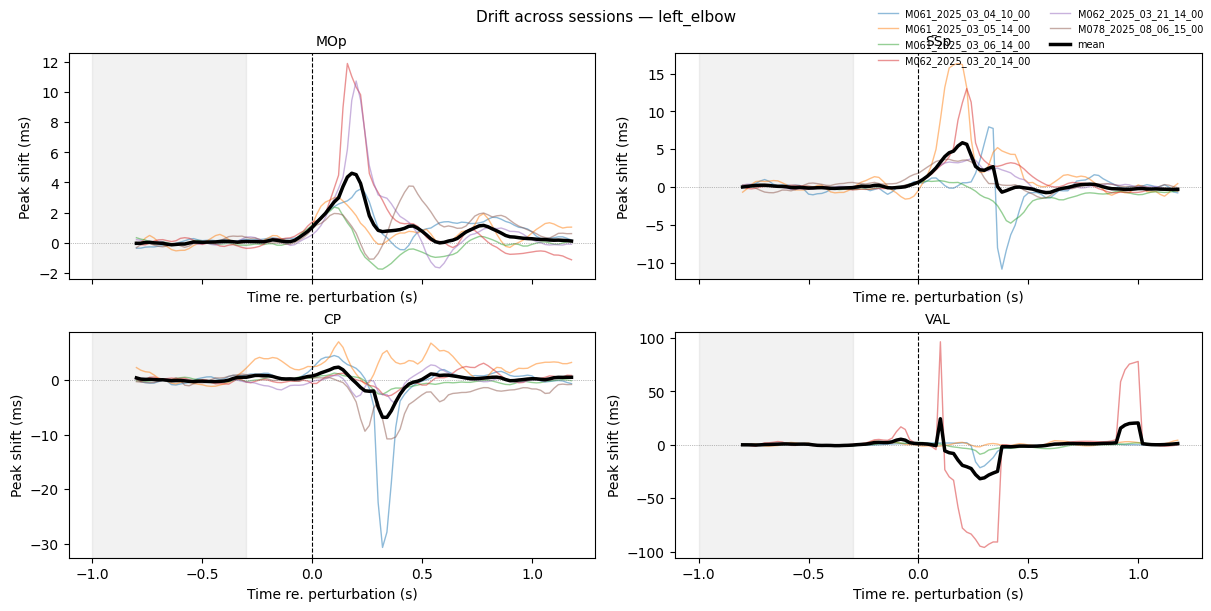

  left_elbow: plotted


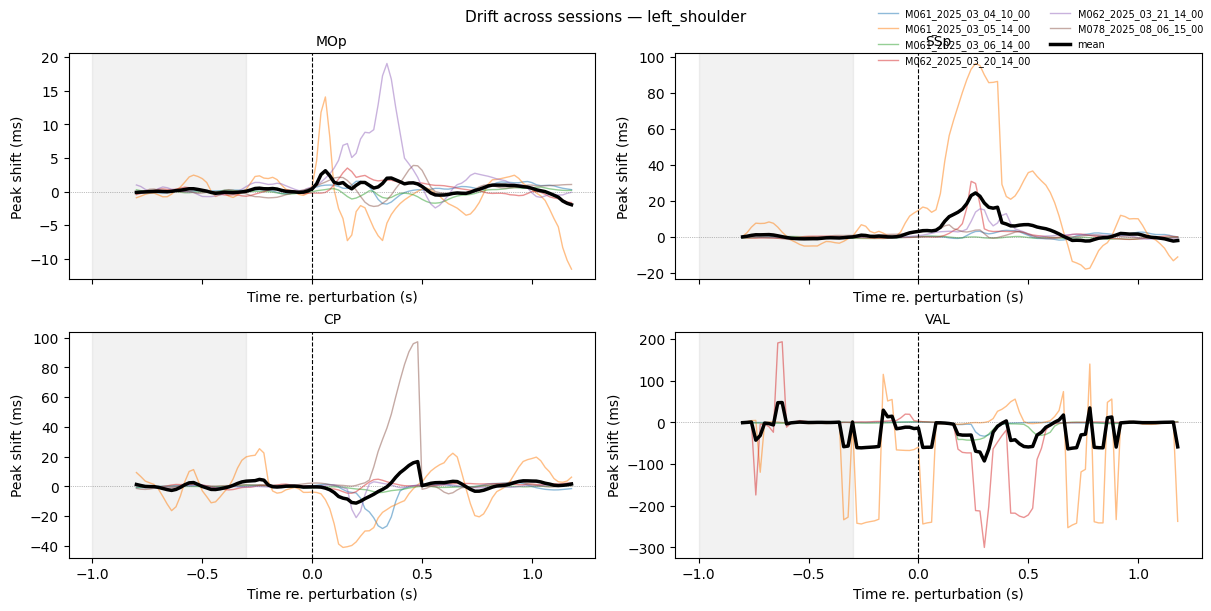

  left_shoulder: plotted


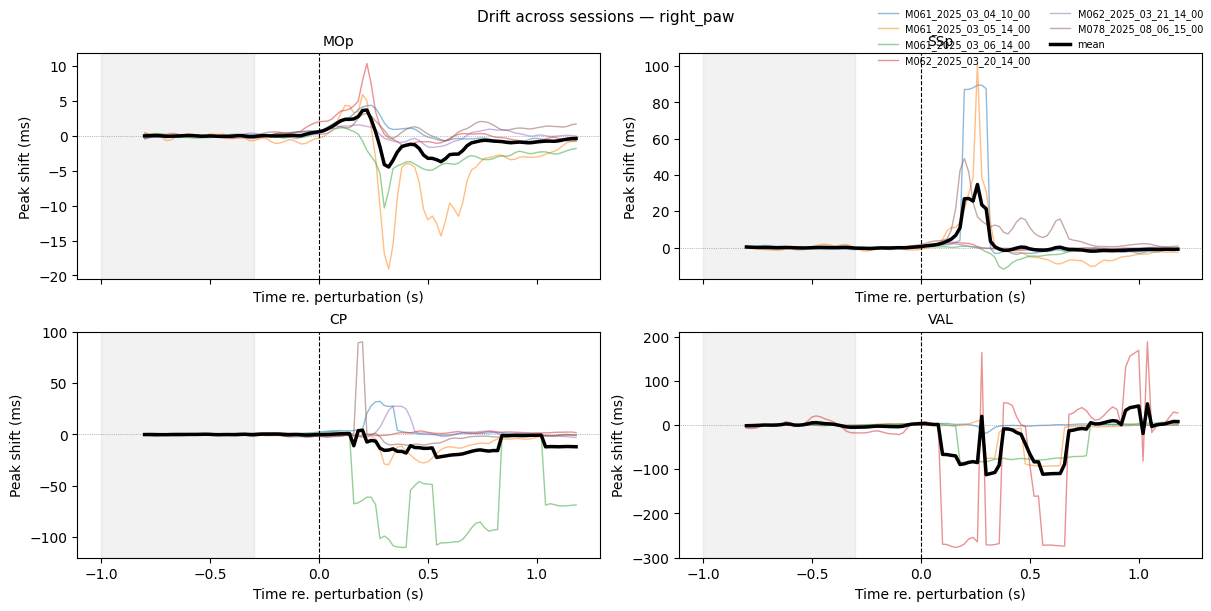

  right_paw: plotted


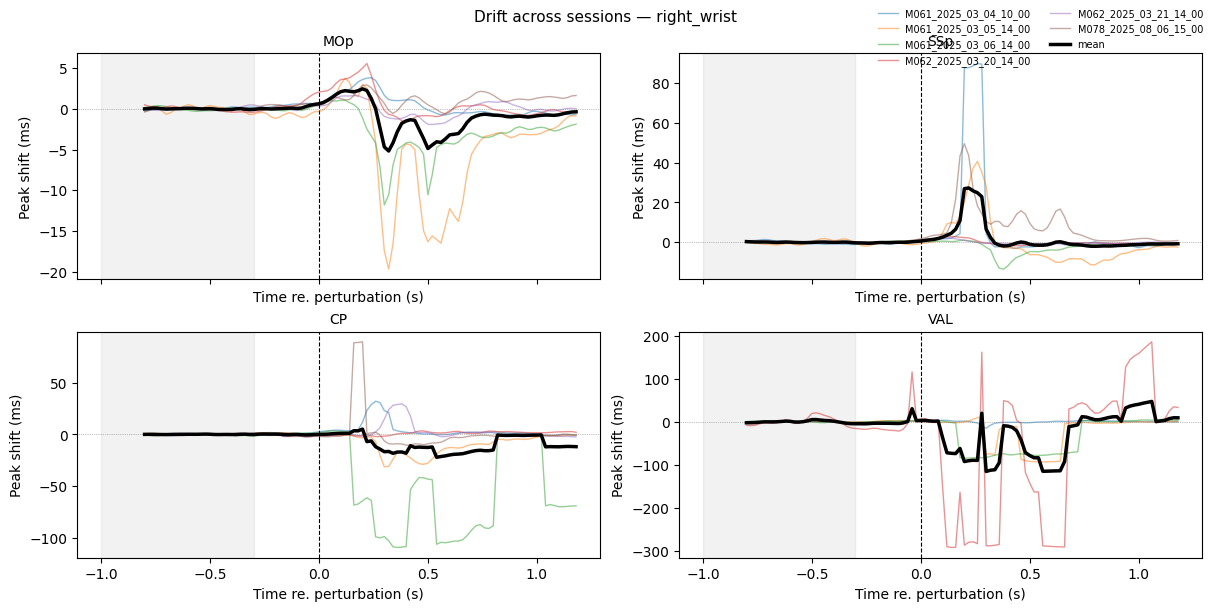

  right_wrist: plotted


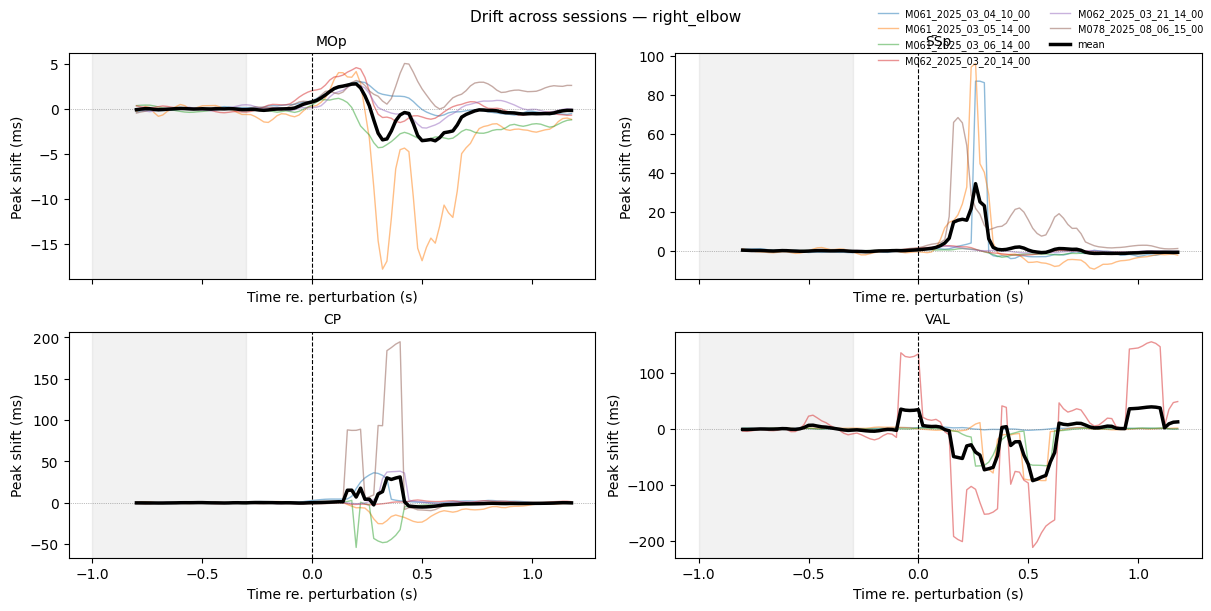

  right_elbow: plotted


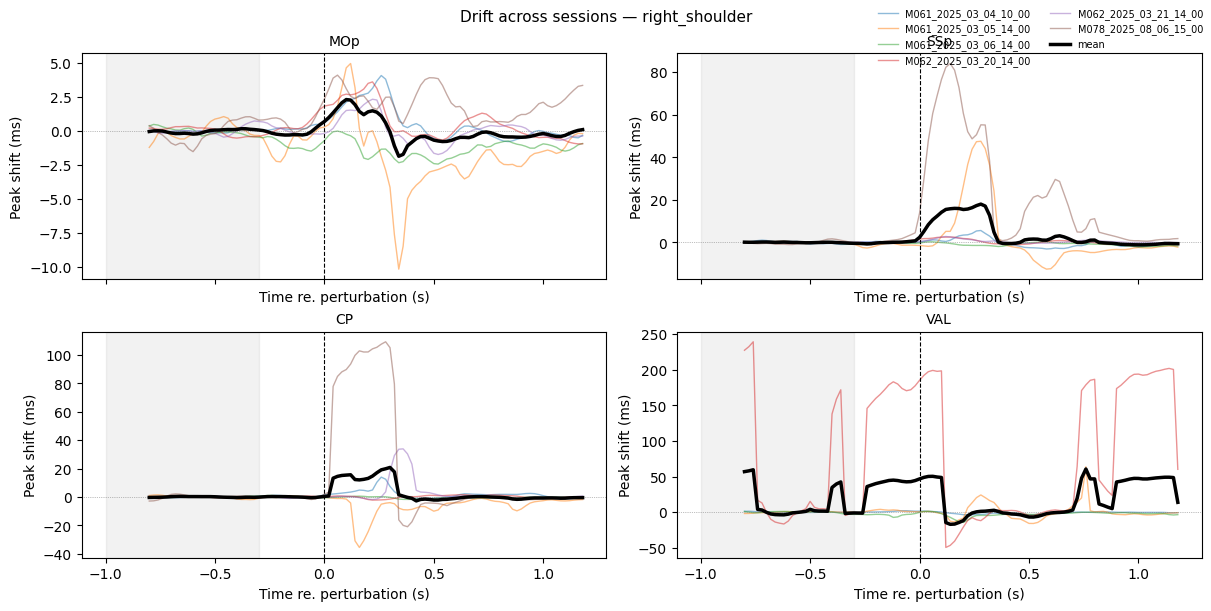

  right_shoulder: plotted


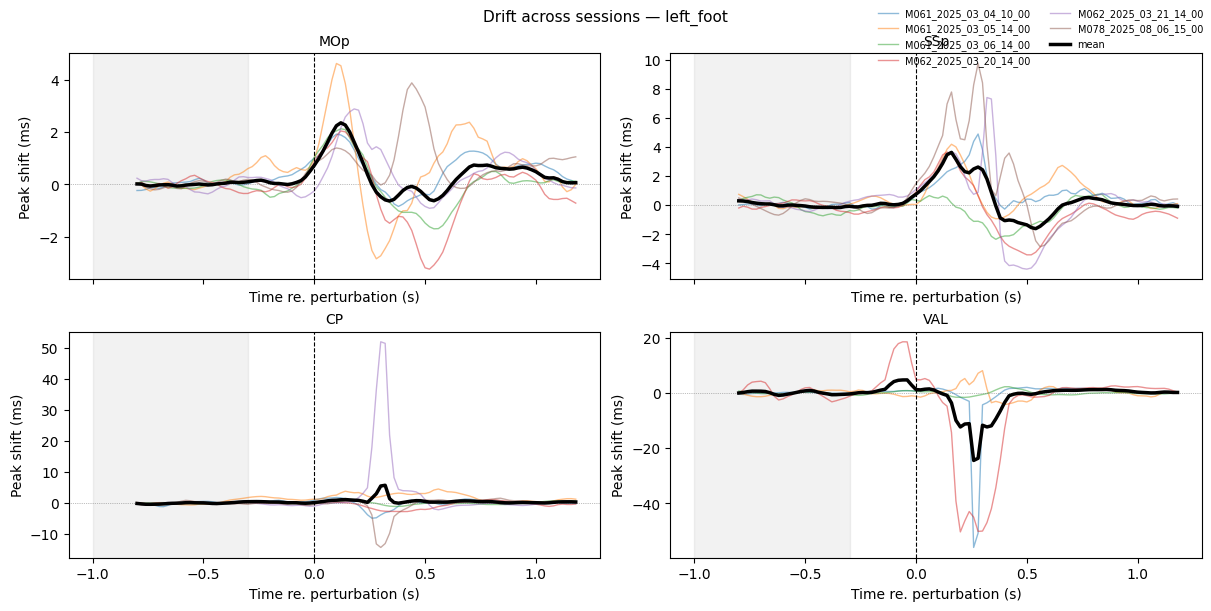

  left_foot: plotted


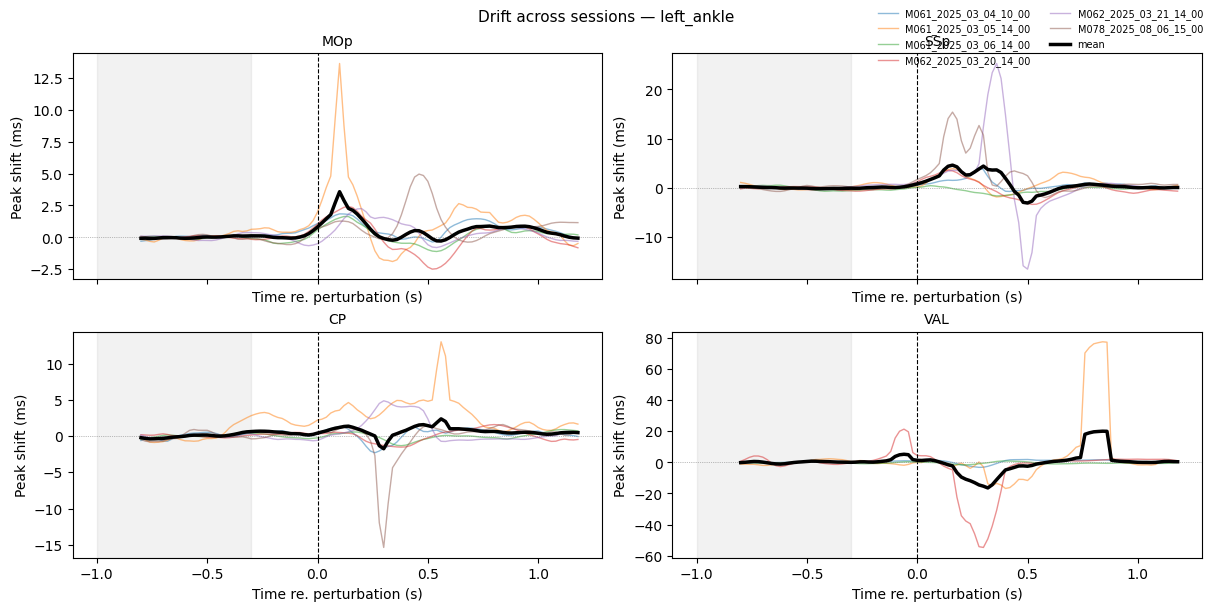

  left_ankle: plotted


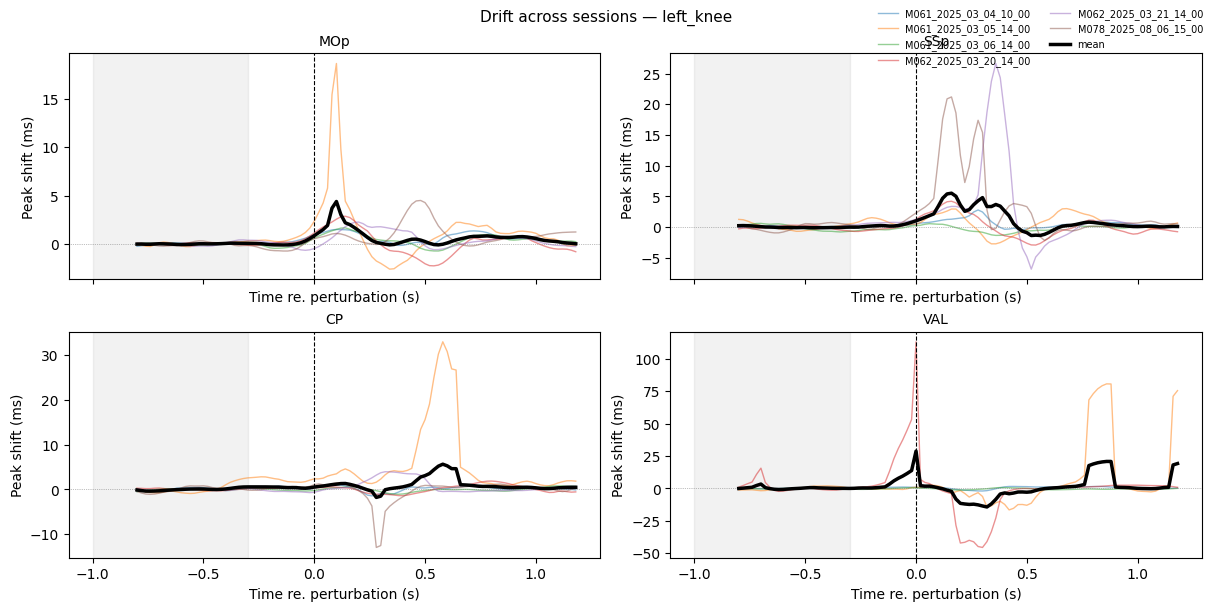

  left_knee: plotted


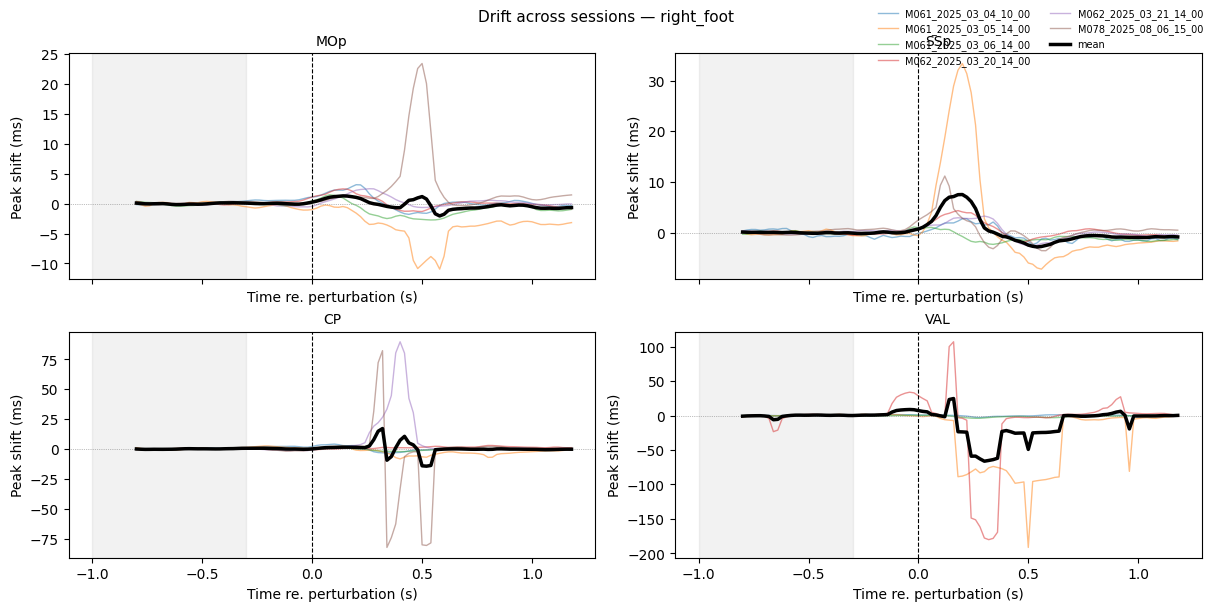

  right_foot: plotted


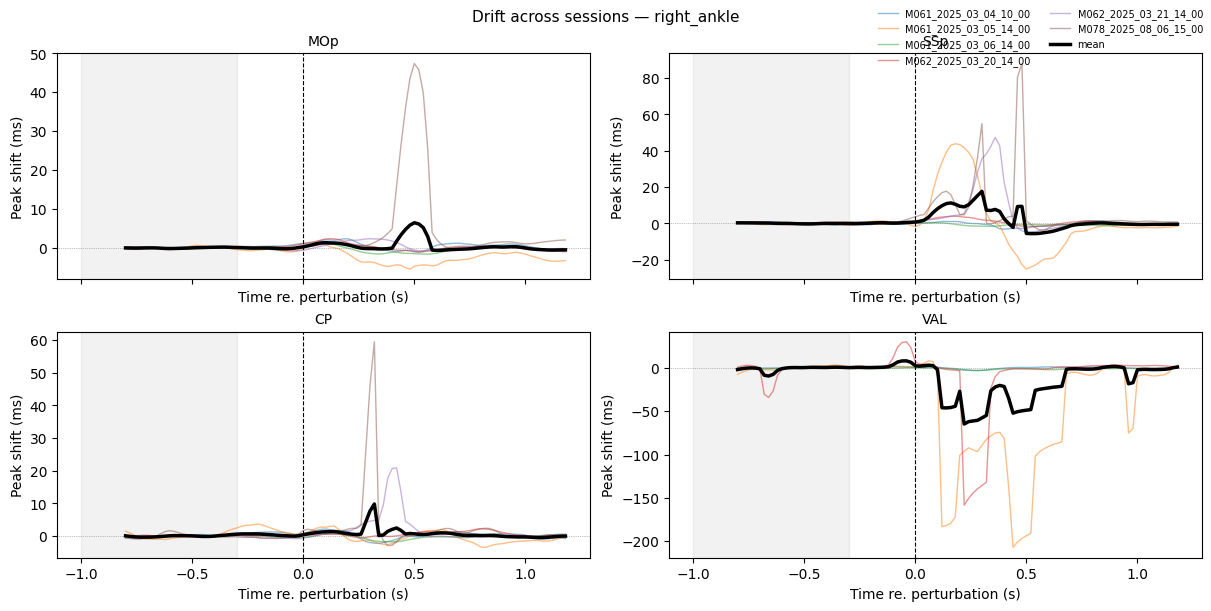

  right_ankle: plotted


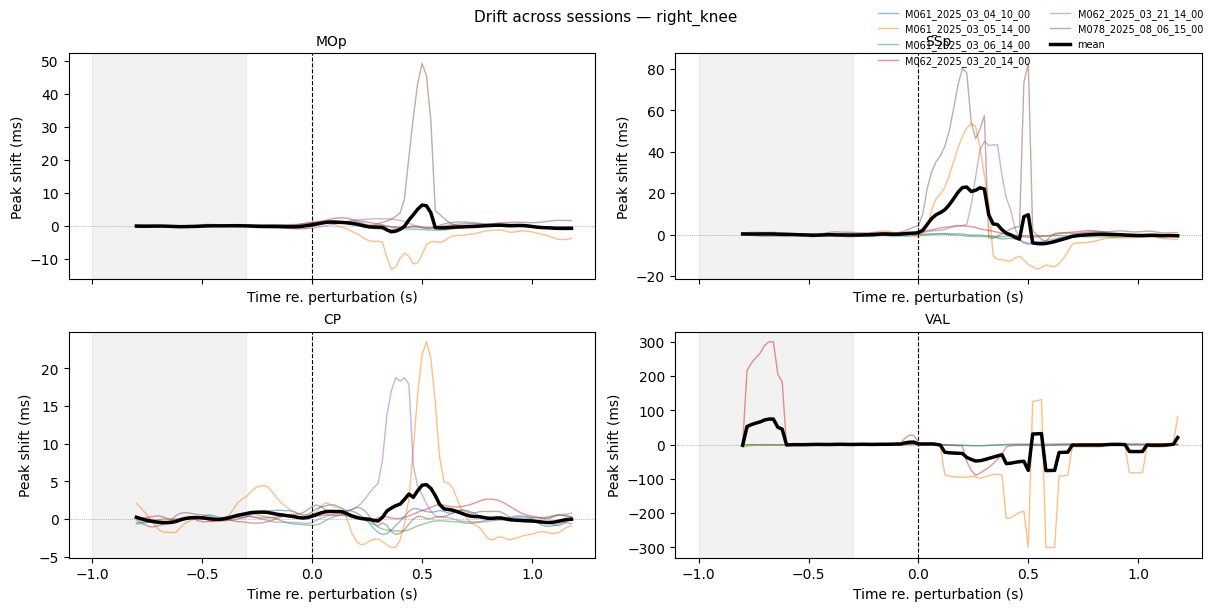

  right_knee: plotted


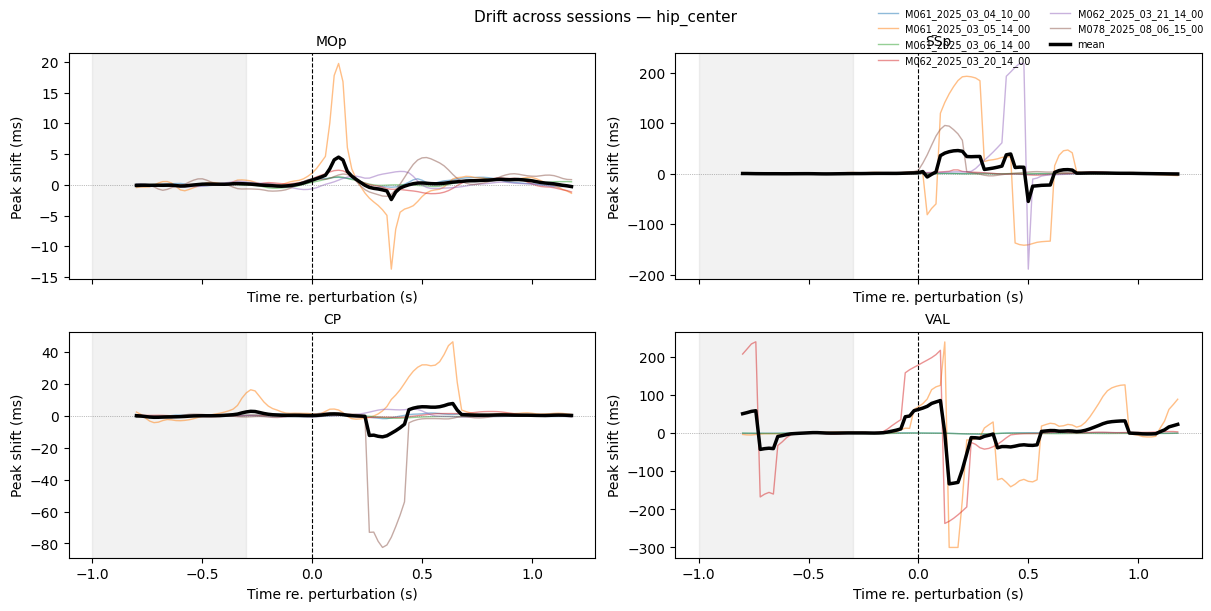

  hip_center: plotted


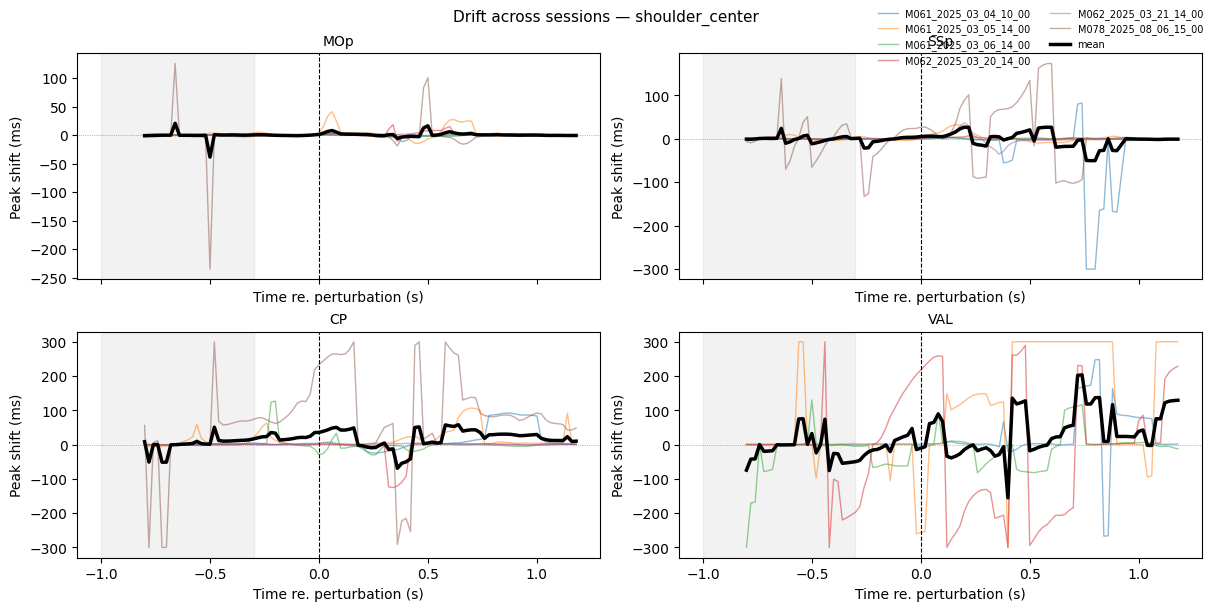

  shoulder_center: plotted


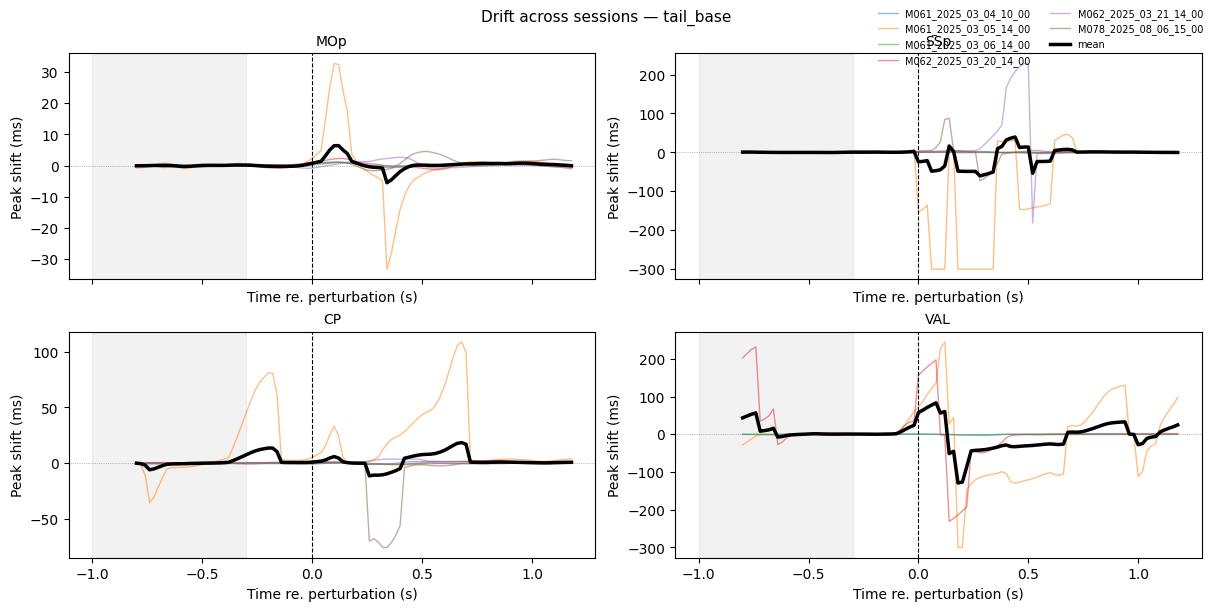

  tail_base: plotted


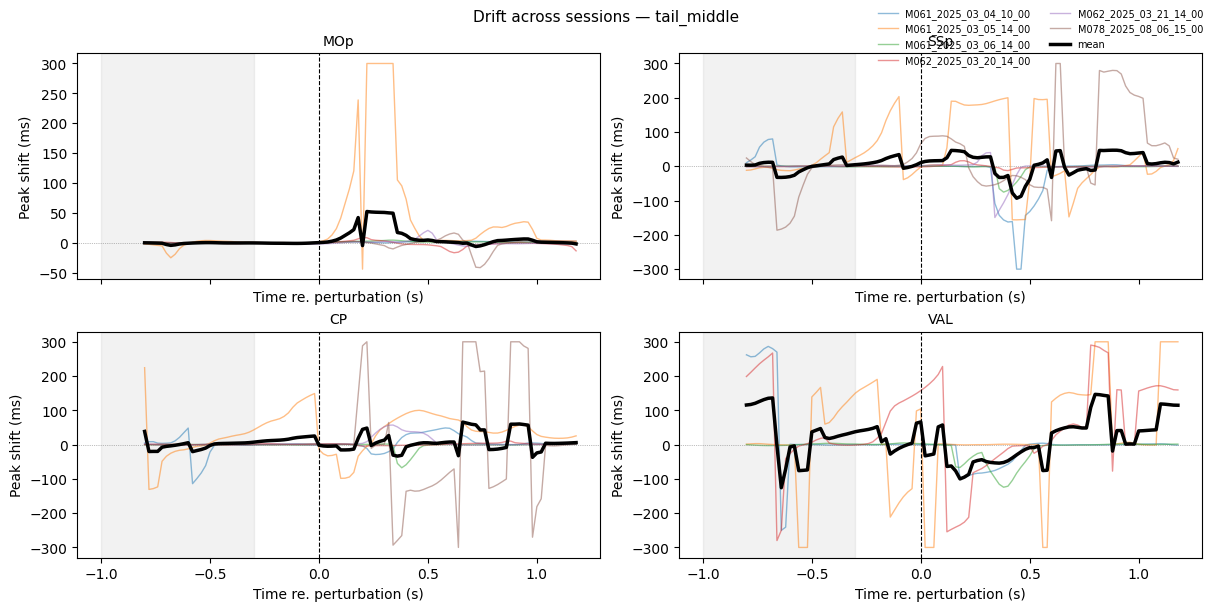

  tail_middle: plotted


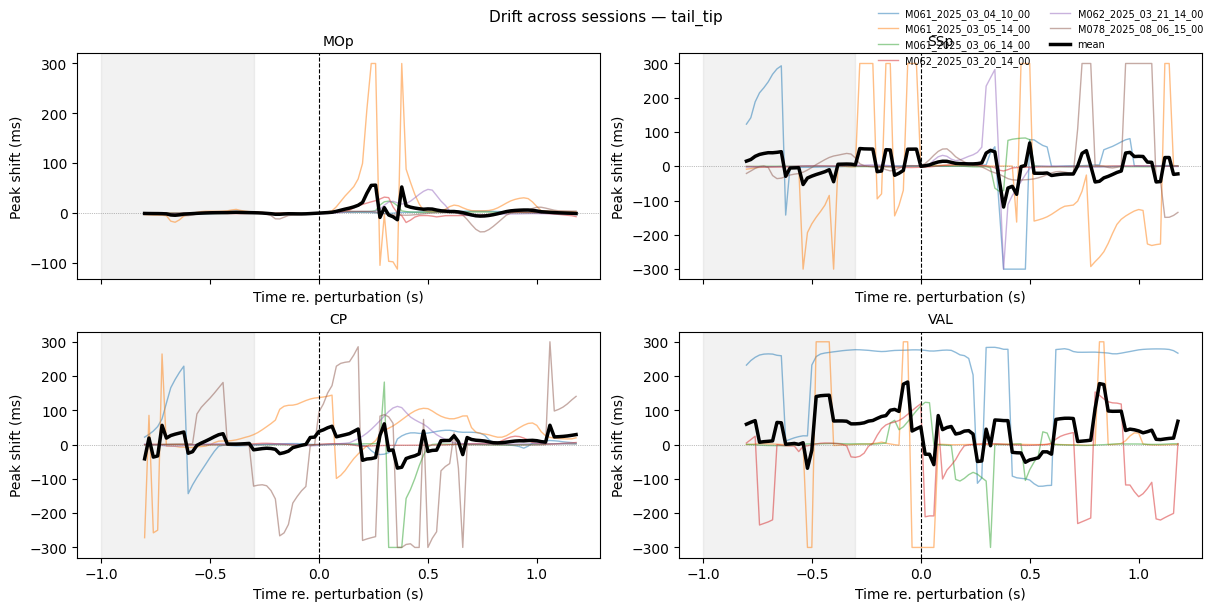

  tail_tip: plotted


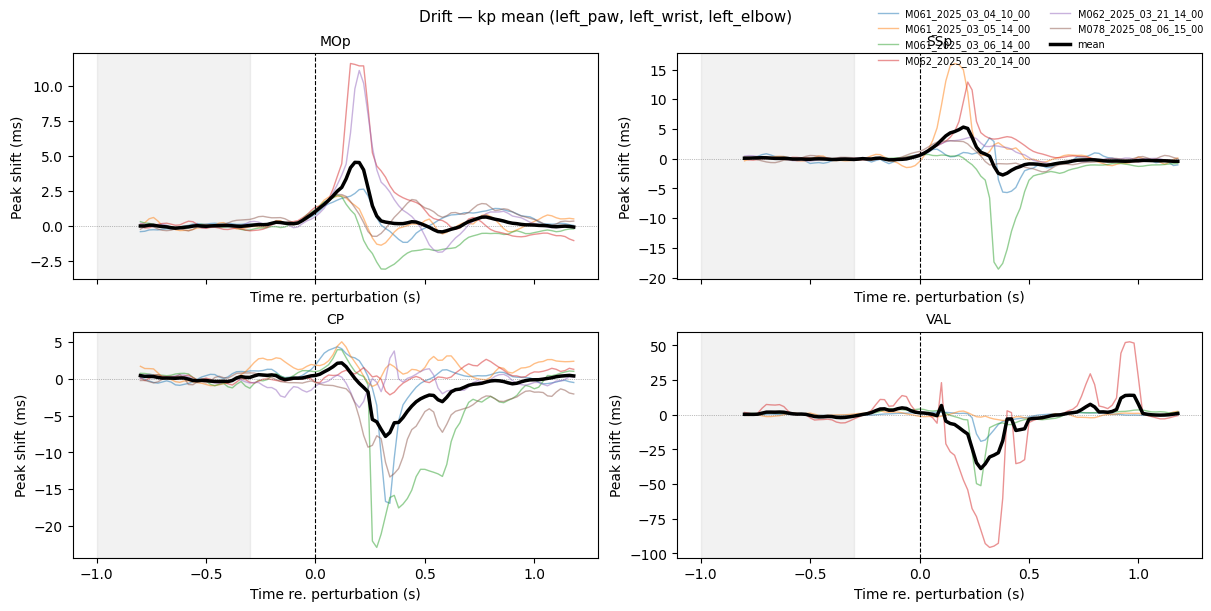

kp-averaged drift: plotted


In [124]:
# ── Drift across sessions — 2×2 (one panel per area), one figure per keypoint ─
# Uses SESSIONS_ALL, EXCLUDE_AREAS, AREAS_PLOT, KP_ORDER_ALL defined above.
# Re-uses _compute_drift / _get_xcorr from the drift cell above.

DRIFT_KP_ALL = kp_order   # from KP_ORDER_ALL filtered to available keypoints

for kp in DRIFT_KP_ALL:
    fig, axes = plt.subplots(2, 2, figsize=(12, 6),
                             sharey=False, sharex=True, constrained_layout=True)
    axes_flat = axes.flatten()

    for ax, area in zip(axes_flat, AREAS_PLOT):
        all_drifts = []
        common_t   = None

        for sess in SESSIONS_ALL:
            if area in EXCLUDE_AREAS.get(sess, []):
                continue

            sess_files = sorted(RESULTS_DIR.glob(f'lagged_dec_{area}_{sess}_npcs*.pkl'))
            if not sess_files:
                continue

            data = load_pkl(sess_files[0])
            if kp not in data:
                continue

            lags_s  = data['_meta']['lags_s']
            lags_ms = lags_s * 1000
            all_t   = np.array(sorted(data[kp].keys()))

            bl_mask = (all_t >= BASELINE_S[0]) & (all_t < BASELINE_S[1])
            if bl_mask.sum() == 0:
                continue
            bl_ref = np.array([data[kp][t].mean(-1) for t in all_t[bl_mask]]).mean(0)

            drift_ms_sess = np.array([
                _compute_drift(data[kp][t].mean(-1), bl_ref, lags_ms)
                for t in all_t
            ])

            ax.plot(all_t, drift_ms_sess, lw=1.0, alpha=0.5, label=sess)

            if common_t is None:
                common_t = all_t
            if len(drift_ms_sess) == len(common_t):
                all_drifts.append(drift_ms_sess)

        # mean across sessions
        if all_drifts and common_t is not None:
            mean_drift = np.mean(all_drifts, axis=0)
            ax.plot(common_t, mean_drift, color='k', lw=2.5, zorder=10, label='mean')

        ax.axvspan(BASELINE_S[0], BASELINE_S[1], color='gray', alpha=0.1)
        ax.axvline(0, color='k', lw=0.8, ls='--')
        ax.axhline(0, color='gray', lw=0.5, ls=':')
        ax.set_title(area, fontsize=10)
        ax.set_xlabel('Time re. perturbation (s)')
        ax.set_ylabel('Peak shift (ms)')

    handles, labels = axes_flat[0].get_legend_handles_labels()
    seen = {}
    for h, l in zip(handles, labels):
        if l not in seen:
            seen[l] = h
    fig.legend(seen.values(), seen.keys(), loc='upper right',
               fontsize=7, frameon=False, ncol=2)
    fig.suptitle(f'Drift across sessions — {kp}', fontsize=11)
    plt.show()
    print(f'  {kp}: plotted')

# ── Grand mean drift: kp-averaged (left_paw + left_wrist + left_elbow) ────────
AVG_KPS = ['left_paw', 'left_wrist', 'left_elbow']

fig, axes = plt.subplots(2, 2, figsize=(12, 6),
                         sharey=False, sharex=True, constrained_layout=True)
axes_flat = axes.flatten()

for ax, area in zip(axes_flat, AREAS_PLOT):
    all_drifts = []
    common_t   = None

    for sess in SESSIONS_ALL:
        if area in EXCLUDE_AREAS.get(sess, []):
            continue

        sess_files = sorted(RESULTS_DIR.glob(f'lagged_dec_{area}_{sess}_npcs*.pkl'))
        if not sess_files:
            continue

        data = load_pkl(sess_files[0])

        # average drift across the 3 keypoints for this session
        kp_drifts = []
        sess_t    = None
        for kp in AVG_KPS:
            if kp not in data:
                continue

            lags_ms = data['_meta']['lags_s'] * 1000
            all_t   = np.array(sorted(data[kp].keys()))
            bl_mask = (all_t >= BASELINE_S[0]) & (all_t < BASELINE_S[1])
            if bl_mask.sum() == 0:
                continue

            bl_ref = np.array([data[kp][t].mean(-1) for t in all_t[bl_mask]]).mean(0)
            d = np.array([_compute_drift(data[kp][t].mean(-1), bl_ref, lags_ms)
                          for t in all_t])
            kp_drifts.append(d)
            if sess_t is None:
                sess_t = all_t

        if not kp_drifts or sess_t is None:
            continue

        # mean across keypoints → single drift curve for this session
        drift_kp_mean = np.mean(kp_drifts, axis=0)

        ax.plot(sess_t, drift_kp_mean, lw=1.0, alpha=0.5, label=sess)

        if common_t is None:
            common_t = sess_t
        if len(drift_kp_mean) == len(common_t):
            all_drifts.append(drift_kp_mean)

    # grand mean across sessions
    if all_drifts and common_t is not None:
        grand_mean = np.mean(all_drifts, axis=0)
        ax.plot(common_t, grand_mean, color='k', lw=2.5, zorder=10, label='mean')

    ax.axvspan(BASELINE_S[0], BASELINE_S[1], color='gray', alpha=0.1)
    ax.axvline(0, color='k', lw=0.8, ls='--')
    ax.axhline(0, color='gray', lw=0.5, ls=':')
    ax.set_title(area, fontsize=10)
    ax.set_xlabel('Time re. perturbation (s)')
    ax.set_ylabel('Peak shift (ms)')

handles, labels = axes_flat[0].get_legend_handles_labels()
seen = {}
for h, l in zip(handles, labels):
    if l not in seen:
        seen[l] = h
fig.legend(seen.values(), seen.keys(), loc='upper right',
           fontsize=7, frameon=False, ncol=2)
fig.suptitle(f'Drift — kp mean ({", ".join(AVG_KPS)})', fontsize=11)
plt.show()
print(f'kp-averaged drift: plotted')


# Drift analysis sessions matched

In [156]:
ALL_SESSIONS = [
    # "M061_2025_03_04_10_00",
    # "M061_2025_03_05_14_00",
    # "M061_2025_03_06_14_00",
    # "M063_2025_03_13_14_00",
    # "M063_2025_03_14_15_30",
    "M062_2025_03_20_14_00",
    # "M062_2025_03_21_14_00",
    # "M078_2025_08_06_15_00",
    # "M086_2025_12_10_15_00",
    # "M103_2026_02_18_15_30",
    # "M103_2026_02_19_15_30",
    # "M106_2026_02_25_15_00",
    # "M106_2026_02_26_16_00",
]

Files found for MOp / M062_2025_03_20_14_00:
  lagged_dec_MOp_M062_2025_03_20_14_00_npcs100.pkl
  lagged_dec_MOp_M062_2025_03_20_14_00_npcs25.pkl
Low PCs: 25   High PCs: 100


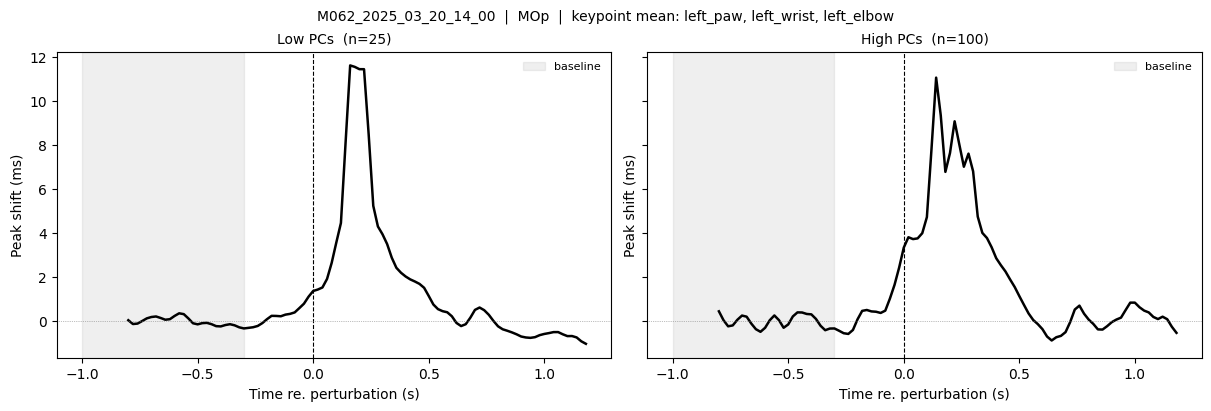

Low  PCs — baseline drift : 0.00 ms
High PCs — baseline drift : 0.01 ms


In [158]:
# ── Drift: low vs high PCs comparison ────────────────────────────────────────
# Parameters
PC_SESSION = 'M062_2025_03_20_14_00'
PC_AREA    = 'MOp'
PC_KPS     = ['left_paw', 'left_wrist', 'left_elbow']   # averaged for the drift

files_for_area = sorted(RESULTS_DIR.glob(f'lagged_dec_{PC_AREA}_{PC_SESSION}_npcs*.pkl'))
print(f"Files found for {PC_AREA} / {PC_SESSION}:")
for f in files_for_area:
    print(f"  {f.name}")

assert len(files_for_area) >= 2, \
    "Need at least 2 pkl files (different n_pcs) — run the pipeline with pc_multiplier=[1,3]"

# sort by n_pcs ascending
files_for_area = sorted(files_for_area,
                        key=lambda f: int(f.stem.split('npcs')[-1]))
data_low  = load_pkl(files_for_area[0])
data_high = load_pkl(files_for_area[-1])
npcs_low  = data_low['_meta']['n_pcs']
npcs_high = data_high['_meta']['n_pcs']
print(f"Low PCs: {npcs_low}   High PCs: {npcs_high}")

def _drift_kp_mean(data, kps):
    """Return (all_t, drift_ms) averaged across kps."""
    lags_ms = data['_meta']['lags_s'] * 1000
    kp_drifts = []
    ref_t     = None
    for kp in kps:
        if kp not in data:
            continue
        all_t   = np.array(sorted(data[kp].keys()))
        bl_mask = (all_t >= BASELINE_S[0]) & (all_t < BASELINE_S[1])
        if bl_mask.sum() == 0:
            continue
        bl_ref = np.array([data[kp][t].mean(-1) for t in all_t[bl_mask]]).mean(0)
        d = np.array([_compute_drift(data[kp][t].mean(-1), bl_ref, lags_ms)
                      for t in all_t])
        kp_drifts.append(d)
        if ref_t is None:
            ref_t = all_t
    return ref_t, np.mean(kp_drifts, axis=0)

t_low,  drift_low  = _drift_kp_mean(data_low,  PC_KPS)
t_high, drift_high = _drift_kp_mean(data_high, PC_KPS)

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4),
                         sharey=True, sharex=True, constrained_layout=True)

for ax, t, drift, npcs, label in [
    (axes[0], t_low,  drift_low,  npcs_low,  f'Low PCs  (n={npcs_low})'),
    (axes[1], t_high, drift_high, npcs_high, f'High PCs  (n={npcs_high})'),
]:
    ax.plot(t, drift, color='k', lw=1.8)
    ax.axvspan(BASELINE_S[0], BASELINE_S[1], color='gray', alpha=0.12, label='baseline')
    ax.axvline(0, color='k', lw=0.8, ls='--')
    ax.axhline(0, color='gray', lw=0.5, ls=':')
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Time re. perturbation (s)')
    ax.set_ylabel('Peak shift (ms)')
    ax.legend(fontsize=8, frameon=False)

fig.suptitle(
    f'{PC_SESSION}  |  {PC_AREA}  |  keypoint mean: {", ".join(PC_KPS)}',
    fontsize=10,
)
plt.show()

print(f"Low  PCs — baseline drift : {drift_low[  (t_low  >= BASELINE_S[0]) & (t_low  < BASELINE_S[1])].mean():.2f} ms")
print(f"High PCs — baseline drift : {drift_high[ (t_high >= BASELINE_S[0]) & (t_high < BASELINE_S[1])].mean():.2f} ms")


In [215]:
SESSIONS_ALL = [
    "M061_2025_03_04_10_00",
    "M061_2025_03_05_14_00",
    "M061_2025_03_06_14_00",
    # "M063_2025_03_13_14_00",
    # "M063_2025_03_14_15_30",
    "M062_2025_03_20_14_00",
    "M062_2025_03_21_14_00",
    "M078_2025_08_06_15_00",
    # "M086_2025_12_10_15_00",
    # "M103_2026_02_18_15_30",
    # "M103_2026_02_19_15_30",
    # "M106_2026_02_25_15_00",
    # "M106_2026_02_26_16_00",
]

Sessions contributing: 6


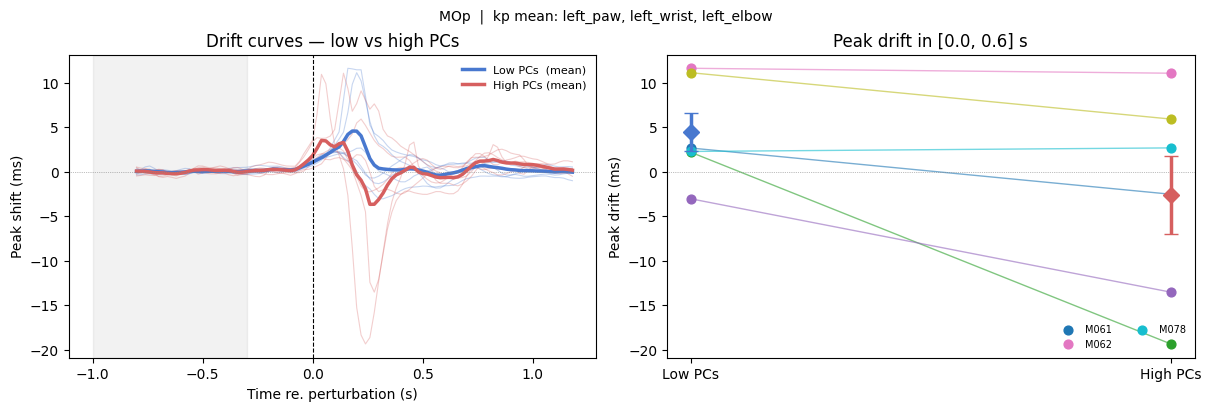

Low  PCs — mean peak : 4.46 ± 2.14 ms (SEM)
High PCs — mean peak : -2.64 ± 4.37 ms (SEM)


In [216]:
# ── More PCs → more drift: overlaid curves + paired dot plot ─────────────────
# Parameters
PAIRED_SESSIONS  = SESSIONS_ALL
PAIRED_AREA      = 'MOp'
PAIRED_KPS       = ['left_paw', 'left_wrist', 'left_elbow']
PEAK_WINDOW_S    = (0.0, 0.6)   # window for extracting peak drift scalar

COL_LOW  = '#4878CF'   # blue  — low PCs
COL_HIGH = '#D65F5F'   # red   — high PCs

# ── collect per-session curves and peak scalars ───────────────────────────────
curves_low, curves_high = [], []   # (n_sessions,) lists of drift arrays
peaks_low,  peaks_high  = [], []   # scalar peak per session
labels_sess = []
common_t    = None

for sess in PAIRED_SESSIONS:
    if PAIRED_AREA in EXCLUDE_AREAS.get(sess, []):
        continue

    files = sorted(RESULTS_DIR.glob(f'lagged_dec_{PAIRED_AREA}_{sess}_npcs*.pkl'),
                   key=lambda f: int(f.stem.split('npcs')[-1]))
    if len(files) < 2:
        print(f"  {sess}: only {len(files)} file(s), skipping")
        continue

    d_low  = load_pkl(files[0])
    d_high = load_pkl(files[-1])

    t_l, dr_l = _drift_kp_mean(d_low,  PAIRED_KPS)
    t_h, dr_h = _drift_kp_mean(d_high, PAIRED_KPS)

    if t_l is None or t_h is None:
        continue

    if common_t is None:
        common_t = t_l

    peak_mask = (t_l >= PEAK_WINDOW_S[0]) & (t_l <= PEAK_WINDOW_S[1])

    curves_low.append(dr_l)
    curves_high.append(dr_h)
    # peak = most negative value post-perturbation (drift goes negative)
    peaks_low.append( dr_l[peak_mask][np.abs(dr_l[peak_mask]).argmax()])
    peaks_high.append(dr_h[peak_mask][np.abs(dr_h[peak_mask]).argmax()])
    labels_sess.append(sess[:4])

peaks_low  = np.array(peaks_low)
peaks_high = np.array(peaks_high)
n_sess     = len(curves_low)
print(f"Sessions contributing: {n_sess}")

# ── mean curves ───────────────────────────────────────────────────────────────
mean_low  = np.mean(curves_low,  axis=0)
mean_high = np.mean(curves_high, axis=0)

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# Left: overlaid temporal curves
ax = axes[0]
for dr in curves_low:
    ax.plot(common_t, dr, color=COL_LOW,  lw=0.8, alpha=0.3)
for dr in curves_high:
    ax.plot(common_t, dr, color=COL_HIGH, lw=0.8, alpha=0.3)
ax.plot(common_t, mean_low,  color=COL_LOW,  lw=2.5, label=f'Low PCs  (mean)')
ax.plot(common_t, mean_high, color=COL_HIGH, lw=2.5, label=f'High PCs (mean)')
ax.axvspan(BASELINE_S[0], BASELINE_S[1], color='gray', alpha=0.1)
ax.axvline(0, color='k', lw=0.8, ls='--')
ax.axhline(0, color='gray', lw=0.5, ls=':')
ax.set_xlabel('Time re. perturbation (s)')
ax.set_ylabel('Peak shift (ms)')
ax.set_title('Drift curves — low vs high PCs')
ax.legend(fontsize=8, frameon=False)

# Right: paired dot plot
ax = axes[1]
x_low, x_high = 0, 1
sess_colors = plt.cm.tab10(np.linspace(0, 1, n_sess))

for i, (pl, ph, lbl) in enumerate(zip(peaks_low, peaks_high, labels_sess)):
    ax.plot([x_low, x_high], [pl, ph], color=sess_colors[i], lw=1.0, alpha=0.6)
    ax.scatter([x_low, x_high], [pl, ph], color=sess_colors[i], s=40, zorder=5, label=lbl)

# mean ± SEM
for x, vals, col in [(x_low, peaks_low, COL_LOW), (x_high, peaks_high, COL_HIGH)]:
    m, se = vals.mean(), vals.std() / np.sqrt(len(vals))
    ax.errorbar(x, m, yerr=se, fmt='D', color=col, ms=8, lw=2.5,
                capsize=5, zorder=10)

ax.set_xticks([x_low, x_high])
ax.set_xticklabels(['Low PCs', 'High PCs'])
ax.axhline(0, color='gray', lw=0.5, ls=':')
ax.set_ylabel('Peak drift (ms)')
ax.set_title(f'Peak drift in [{PEAK_WINDOW_S[0]}, {PEAK_WINDOW_S[1]}] s')
handles, labels_ = ax.get_legend_handles_labels()
seen = {}
for h, l in zip(handles, labels_):
    if l not in seen: seen[l] = h
ax.legend(seen.values(), seen.keys(), fontsize=7, frameon=False,
          loc='lower right', ncol=2)

fig.suptitle(
    f'{PAIRED_AREA}  |  kp mean: {", ".join(PAIRED_KPS)}',
    fontsize=10,
)
plt.show()

print(f"Low  PCs — mean peak : {peaks_low.mean():.2f} ± {peaks_low.std()/np.sqrt(n_sess):.2f} ms (SEM)")
print(f"High PCs — mean peak : {peaks_high.mean():.2f} ± {peaks_high.std()/np.sqrt(n_sess):.2f} ms (SEM)")


Sessions: 1  |  mean peak diff: -1.90 ± 0.00 ms (SEM)


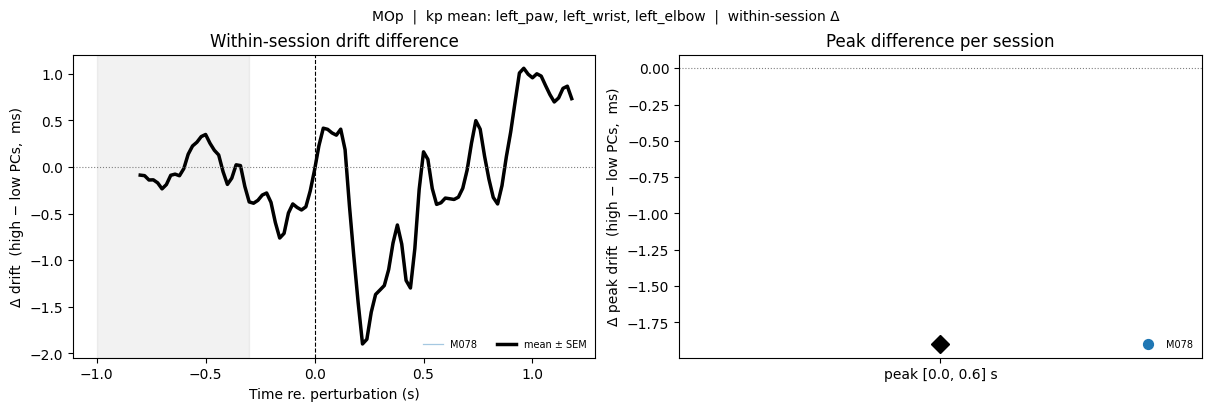

In [193]:
# ── More PCs → more drift: within-session difference ─────────────────────────
# Parameters (reuses PAIRED_SESSIONS, PAIRED_AREA, PAIRED_KPS, PEAK_WINDOW_S)

# ── collect within-session difference curves ──────────────────────────────────
diff_curves  = []   # drift_high - drift_low per session
diff_peaks   = []   # scalar: peak of difference curve in PEAK_WINDOW_S
labels_diff  = []
common_t_d   = None

for sess in PAIRED_SESSIONS:
    if PAIRED_AREA in EXCLUDE_AREAS.get(sess, []):
        continue

    files = sorted(RESULTS_DIR.glob(f'lagged_dec_{PAIRED_AREA}_{sess}_npcs*.pkl'),
                   key=lambda f: int(f.stem.split('npcs')[-1]))
    if len(files) < 2:
        continue

    d_low  = load_pkl(files[0])
    d_high = load_pkl(files[-1])

    t_l, dr_l = _drift_kp_mean(d_low,  PAIRED_KPS)
    t_h, dr_h = _drift_kp_mean(d_high, PAIRED_KPS)

    if t_l is None or t_h is None or len(dr_l) != len(dr_h):
        continue

    diff = dr_h - dr_l   # positive = high PCs drifts more

    if common_t_d is None:
        common_t_d = t_l

    peak_mask = (t_l >= PEAK_WINDOW_S[0]) & (t_l <= PEAK_WINDOW_S[1])
    diff_peaks.append(diff[peak_mask][np.abs(diff[peak_mask]).argmax()])
    diff_curves.append(diff)
    labels_diff.append(sess[:4])

diff_curves = np.array(diff_curves)   # (n_sess, n_t)
diff_peaks  = np.array(diff_peaks)
n_d         = len(diff_curves)

mean_diff = diff_curves.mean(0)
sem_diff  = diff_curves.std(0)# / np.sqrt(n_d)

print(f"Sessions: {n_d}  |  mean peak diff: {diff_peaks.mean():.2f} ± {diff_peaks.std()/np.sqrt(n_d):.2f} ms (SEM)")

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# Left: difference curves + mean ± SEM
ax = axes[0]
sess_colors = plt.cm.tab10(np.linspace(0, 1, n_d))
for i, (diff, lbl) in enumerate(zip(diff_curves, labels_diff)):
    ax.plot(common_t_d, diff, color=sess_colors[i], lw=0.9, alpha=0.4, label=lbl)
ax.fill_between(common_t_d, mean_diff - sem_diff, mean_diff + sem_diff,
                color='k', alpha=0.15)
ax.plot(common_t_d, mean_diff, color='k', lw=2.5, label='mean ± SEM')
ax.axvspan(BASELINE_S[0], BASELINE_S[1], color='gray', alpha=0.1)
ax.axvline(0,  color='k',    lw=0.8, ls='--')
ax.axhline(0,  color='gray', lw=0.8, ls=':')
ax.set_xlabel('Time re. perturbation (s)')
ax.set_ylabel('Δ drift  (high − low PCs,  ms)')
ax.set_title('Within-session drift difference')
ax.legend(fontsize=7, frameon=False, ncol=2)

# Right: dot plot of peak difference per session
ax = axes[1]
for i, (dp, lbl) in enumerate(zip(diff_peaks, labels_diff)):
    ax.scatter(0, dp, color=sess_colors[i], s=50, zorder=5, label=lbl)
m, se = diff_peaks.mean(), diff_peaks.std() / np.sqrt(n_d)
ax.errorbar(0, m, yerr=se, fmt='D', color='k', ms=9, lw=2.5, capsize=6, zorder=10)
ax.axhline(0, color='gray', lw=0.8, ls=':')
ax.set_xticks([0])
ax.set_xticklabels([f'peak [{PEAK_WINDOW_S[0]}, {PEAK_WINDOW_S[1]}] s'])
ax.set_ylabel('Δ peak drift  (high − low PCs,  ms)')
ax.set_title('Peak difference per session')
ax.legend(fontsize=7, frameon=False, loc='lower right', ncol=2)

fig.suptitle(
    f'{PAIRED_AREA}  |  kp mean: {", ".join(PAIRED_KPS)}  |  within-session Δ',
    fontsize=10,
)
plt.show()


In [ ]:
SESSIONS_ALL = [
    # "M061_2025_03_04_10_00",
    # "M061_2025_03_05_14_00",
    # "M061_2025_03_06_14_00",
    # "M063_2025_03_13_14_00",
    # "M063_2025_03_14_15_30",
    # "M062_2025_03_20_14_00",
    # "M062_2025_03_21_14_00",
    "M078_2025_08_06_15_00",
    # "M086_2025_12_10_15_00",
    # "M103_2026_02_18_15_30",
    # "M103_2026_02_19_15_30",
    # "M106_2026_02_25_15_00",
    # "M106_2026_02_26_16_00",
]

Sessions: 6  |  area: MOp  |  lag range: (-0.15, 0.15)
Low PCs: 25   High PCs: 100


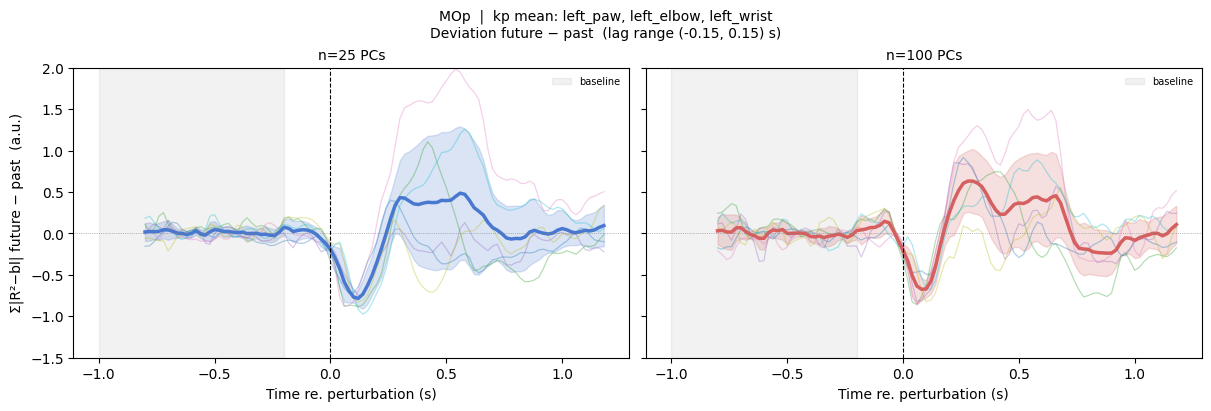

n=25 PCs — mean post-perturb: 0.0351 ± 0.1385 (SEM)
n=100 PCs — mean post-perturb: 0.0721 ± 0.0768 (SEM)


In [256]:
# ── Future − past deviation from baseline — low vs high PCs ──────────────────
# Method: for each time point t, compute sum|curve(lag) - baseline(lag)|
# separately on the past (lag<0) and future (lag>0) sides, then take the
# difference future - past. Baseline curve = mean R²(lag) over BASELINE_S.

# ── Parameters ────────────────────────────────────────────────────────────────
FP_SESSIONS  = [
    'M078_2025_08_06_15_00',
    'M061_2025_03_04_10_00',
    'M061_2025_03_05_14_00',
    'M061_2025_03_06_14_00',
    'M062_2025_03_20_14_00',
    'M062_2025_03_21_14_00',
    # 'M086_2025_12_10_15_00',
]
FP_AREA      = 'MOp'
FP_KPS       = ['left_paw', 'left_elbow', 'left_wrist']
# FP_KPS       = ['shoulder_center']

FP_LAG_RANGE = (-0.15, 0.15)   # s — lag window for the deviation integral
FP_BASELINE  = (-1.0, -0.2)    # s — baseline window
FP_COL_LOW   = '#4878CF'
FP_COL_HIGH  = '#D65F5F'

FP_EXCLUDE = {
    'M062_2025_03_20_14_00': ['VAL'],
    'M062_2025_03_21_14_00': ['VAL'],
    'M086_2025_12_10_15_00': ['VAL'],
}

# ── helpers ───────────────────────────────────────────────────────────────────
def _deviation_fp(curve, baseline, lags_s):
    """Σ|curve - baseline| on future side  minus  past side."""
    past_m   = lags_s < 0
    future_m = lags_s > 0
    return (np.sum(np.abs(curve[future_m] - baseline[future_m]))
          - np.sum(np.abs(curve[past_m]   - baseline[past_m])))

def _fp_series(data, kps, lag_m, lags_masked, bl_s):
    all_t   = np.array(sorted(data[kps[0]].keys()))
    bl_mask = (all_t >= bl_s[0]) & (all_t < bl_s[1])
    kp_series = []
    for kp in kps:
        if kp not in data:
            continue
        bl_ref = np.array([data[kp][t].mean(-1)[lag_m]
                           for t in all_t[bl_mask]]).mean(0)
        kp_series.append(np.array([
            _deviation_fp(data[kp][t].mean(-1)[lag_m], bl_ref, lags_masked)
            for t in all_t
        ]))
    return all_t, np.mean(kp_series, axis=0)

# ── collect ───────────────────────────────────────────────────────────────────
fp_low, fp_high = [], []
common_t_fp     = None

for sess in FP_SESSIONS:
    if FP_AREA in FP_EXCLUDE.get(sess, []):
        continue

    files = sorted(RESULTS_DIR.glob(f'lagged_dec_{FP_AREA}_{sess}_npcs*.pkl'),
                   key=lambda f: int(f.stem.split('npcs')[-1]))
    if len(files) < 2:
        print(f"  {sess}: only {len(files)} file(s), skipping")
        continue

    d_low  = load_pkl(files[0])
    d_high = load_pkl(files[-1])
    lags_s = d_low['_meta']['lags_s']
    lag_m  = (lags_s >= FP_LAG_RANGE[0]) & (lags_s <= FP_LAG_RANGE[1])
    lags_masked = lags_s[lag_m]

    t_l, s_l = _fp_series(d_low,  FP_KPS, lag_m, lags_masked, FP_BASELINE)
    t_h, s_h = _fp_series(d_high, FP_KPS, lag_m, lags_masked, FP_BASELINE)

    if common_t_fp is None:
        common_t_fp = t_l
    fp_low.append(s_l)
    fp_high.append(s_h)

fp_low  = np.array(fp_low)
fp_high = np.array(fp_high)
n_fp    = len(fp_low)
sess_colors = plt.cm.tab10(np.linspace(0, 1, n_fp))

npcs_low  = load_pkl(files[0])['_meta']['n_pcs']
npcs_high = load_pkl(files[-1])['_meta']['n_pcs']
print(f"Sessions: {n_fp}  |  area: {FP_AREA}  |  lag range: {FP_LAG_RANGE}")
print(f"Low PCs: {npcs_low}   High PCs: {npcs_high}")

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4),
                         sharey=True, sharex=True, constrained_layout=True)

for ax, curves, npcs, col in [
    (axes[0], fp_low,  npcs_low,  FP_COL_LOW),
    (axes[1], fp_high, npcs_high, FP_COL_HIGH),
]:
    mean_ = curves.mean(0)
    sem_  = curves.std(0)# / np.sqrt(n_fp)

    for i, s in enumerate(curves):
        ax.plot(common_t_fp, s, color=sess_colors[i], lw=0.9, alpha=0.35)
    ax.fill_between(common_t_fp, mean_ - sem_, mean_ + sem_, color=col, alpha=0.2)
    ax.plot(common_t_fp, mean_, color=col, lw=2.5)

    ax.axvspan(FP_BASELINE[0], FP_BASELINE[1], color='gray', alpha=0.1, label='baseline')
    ax.axvline(0, color='k',    lw=0.8, ls='--')
    ax.axhline(0, color='gray', lw=0.5, ls=':')
    ax.set_title(f'n={npcs} PCs', fontsize=10)
    ax.set_xlabel('Time re. perturbation (s)')
    ax.legend(fontsize=7, frameon=False)

axes[0].set_ylabel('Σ|R²−bl| future − past  (a.u.)')
axes[0].set_ylim(-1.5, 2)
fig.suptitle(
    f'{FP_AREA}  |  kp mean: {", ".join(FP_KPS)}\n'
    f'Deviation future − past  (lag range {FP_LAG_RANGE} s)',
    fontsize=10,
)
plt.show()

for curves, npcs in [(fp_low, npcs_low), (fp_high, npcs_high)]:
    post = curves[:, common_t_fp > 0].mean(axis=1)
    print(f"n={npcs} PCs — mean post-perturb: {post.mean():.4f} ± {post.std()/np.sqrt(n_fp):.4f} (SEM)")


Session: M061_2025_03_06_14_00  |  Area: MOp  |  KP: left_paw
t = 0.120 s  |  dev_past=1.9919  dev_future=1.4373  diff=-0.5546


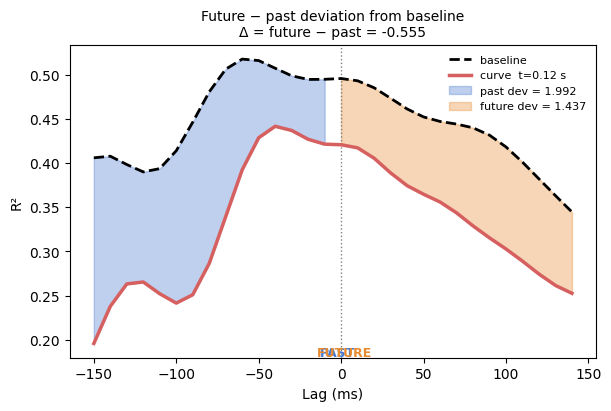

In [241]:
# ── Helper: visualise future − past deviation from baseline ───────────────────
# Shows one example R²(lag) curve vs baseline, with shaded deviations.

# ── Parameters ────────────────────────────────────────────────────────────────
HELPER_SESSION  = 'M061_2025_03_06_14_00'
HELPER_AREA     = 'MOp'
HELPER_KP       = 'left_paw'
HELPER_T        = 0.12          # s — time point to show (post-perturbation)
HELPER_LAG_RANGE = (-0.15, 0.15)
HELPER_BASELINE  = (-1.0, -0.3)

# ── load ──────────────────────────────────────────────────────────────────────
h_files = sorted(RESULTS_DIR.glob(f'lagged_dec_{HELPER_AREA}_{HELPER_SESSION}_npcs*.pkl'),
                 key=lambda f: int(f.stem.split('npcs')[-1]))
assert h_files, f"No file for {HELPER_AREA} / {HELPER_SESSION}"
h_data  = load_pkl(h_files[0])   # use low-PC file for the illustration

lags_s  = h_data['_meta']['lags_s']
lag_m   = (lags_s >= HELPER_LAG_RANGE[0]) & (lags_s <= HELPER_LAG_RANGE[1])
lags    = lags_s[lag_m] * 1000   # ms for x-axis

all_t   = np.array(sorted(h_data[HELPER_KP].keys()))
bl_mask = (all_t >= HELPER_BASELINE[0]) & (all_t < HELPER_BASELINE[1])
bl_ref  = np.array([h_data[HELPER_KP][t].mean(-1)[lag_m]
                    for t in all_t[bl_mask]]).mean(0)

# pick closest available time point
t_idx  = np.argmin(np.abs(all_t - HELPER_T))
t_used = all_t[t_idx]
curve  = h_data[HELPER_KP][t_used].mean(-1)[lag_m]

past_m   = lags < 0
future_m = lags > 0
dev_past   = np.sum(np.abs(curve[past_m]   - bl_ref[past_m]))
dev_future = np.sum(np.abs(curve[future_m] - bl_ref[future_m]))

print(f"Session: {HELPER_SESSION}  |  Area: {HELPER_AREA}  |  KP: {HELPER_KP}")
print(f"t = {t_used:.3f} s  |  dev_past={dev_past:.4f}  dev_future={dev_future:.4f}  diff={dev_future-dev_past:.4f}")

# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)

# baseline and example curve
ax.plot(lags, bl_ref, color='k',       lw=2,   ls='--', label='baseline', zorder=3)
ax.plot(lags, curve,  color='#D65F5F', lw=2.5, label=f'curve  t={t_used:.2f} s', zorder=3)

# shaded deviation — past (lag < 0)
ax.fill_between(lags[past_m], bl_ref[past_m], curve[past_m],
                where=curve[past_m] != bl_ref[past_m],
                color='#4878CF', alpha=0.35, label=f'past dev = {dev_past:.3f}')

# shaded deviation — future (lag > 0)
ax.fill_between(lags[future_m], bl_ref[future_m], curve[future_m],
                where=curve[future_m] != bl_ref[future_m],
                color='#E88A2E', alpha=0.35, label=f'future dev = {dev_future:.3f}')

# annotations
ax.axvline(0, color='gray', lw=1.0, ls=':')
ax.text(-2, ax.get_ylim()[0] + 0.002, 'PAST', ha='center', fontsize=9,
        color='#4878CF', fontweight='bold')
ax.text( 2, ax.get_ylim()[0] + 0.002, 'FUTURE', ha='center', fontsize=9,
        color='#E88A2E', fontweight='bold')

ax.set_xlabel('Lag (ms)')
ax.set_ylabel('R²')
ax.set_title(
    f'Future − past deviation from baseline\n'
    f'Δ = future − past = {dev_future - dev_past:.3f}',
    fontsize=10,
)
ax.legend(fontsize=8, frameon=False)
plt.show()


# Check predictions

In [ ]:
ALL_SESSIONS = [
    # "M061_2025_03_04_10_00",
    # "M061_2025_03_05_14_00",
    "M061_2025_03_06_14_00",
    # "M063_2025_03_13_14_00",
    # "M063_2025_03_14_15_30",
    # "M062_2025_03_20_14_00",
    # "M062_2025_03_21_14_00",
    # "M078_2025_08_06_15_00",
    # "M086_2025_12_10_15_00",
    # "M103_2026_02_18_15_30",
    # "M103_2026_02_19_15_30",
    # "M106_2026_02_25_15_00",
    # "M106_2026_02_26_16_00",
]

In [15]:
-150 * 0.02

-3.0

In [16]:
all_session_processed = dsp.load_sessions_for_trial_analyses(
    ALL_SESSIONS, use_sem_dropping=True, rates=False, rel_start=-100, rel_end=150
)

perturb_td = all_session_processed['M061_2025_03_06_14_00']["td"]
perturb_td_shuff = perturb_td.sample(frac=1, random_state=42).reset_index(drop=False)


Loading sessions:   0%|          | 0/1 [00:00<?, ?it/s]


M061_2025_03_06_14_00
fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)
  No disturb_mean — skipping trial dropping.


Loading sessions: 100%|██████████| 1/1 [00:34<00:00, 34.65s/it]


Loaded 1/1 sessions successfully.


In [141]:
perturb_td_shuff.MOp_spikes.values[0].shape

(501, 199)

Text(0.5, 1.0, 'std = 0.05')

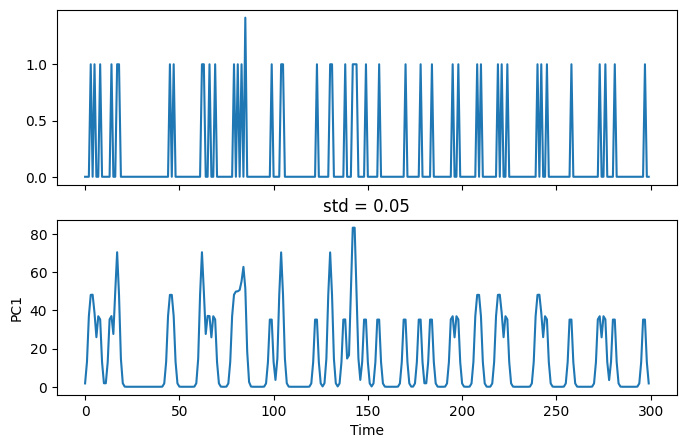

In [98]:
fig, axs = plt.subplots(2, 1, figsize=(8, 5), sharex='all')
ax = axs[1]
axs[0].plot(perturb_td_shuff.MOp_spikes.values[0][0:300, 1])
ax.plot(perturb_td_shuff.MOp_rates.values[0][0:300, 1])

ax.set_xlabel('Time')
ax.set_ylabel('PC1')
ax.set_title('std = 0.05')

In [ ]:
pre_perturb = np.stack(perturb_td_shuff.MOp_rates_pca.values)[:, 100:200, :25]
bhv = np.stack(perturb_td_shuff.left_elbow.values)[:, 100:200, :]
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")

r2s = cross_val_score(
    Ridge(0.01),
    pre_perturb.reshape(-1, pre_perturb.shape[-1]),
    bhv.reshape(-1, bhv.shape[-1]),
    cv=5,
    scoring=vw_r2_scorer
)

r2s.mean()

0.2104601631100565

In [54]:
pre_perturb = np.stack(perturb_td_shuff.MOp_rates_pca.values)[:, 200:250, :25]
bhv = np.stack(perturb_td_shuff.left_elbow.values)[:, 200:250, :]

r2s = cross_val_score(
    Ridge(0.01),
    pre_perturb.reshape(-1, pre_perturb.shape[-1]),
    bhv.reshape(-1, bhv.shape[-1]),
    cv=5,
    scoring=vw_r2_scorer
)

r2s.mean()

0.30773479719041996

In [55]:
pre_perturb = np.stack(perturb_td_shuff.MOp_rates_pca.values)[:, 200:250, :25]
bhv = np.stack(perturb_td_shuff.left_elbow.values)[:, 200:250, :]

y_pred = cross_val_predict(
    Ridge(0.01),
    pre_perturb.reshape(-1, pre_perturb.shape[-1]),
    bhv.reshape(-1, bhv.shape[-1]),
    cv=5
)

y_pred.shape

(10750, 3)

In [18]:
vw_r2_scorer = make_scorer(r2_score, multioutput="variance_weighted")


0.16906327196832413 0.015157392137803911


Text(0.5, 1.0, 'R2 cv 5 fold 0.169. Pre - perturb')

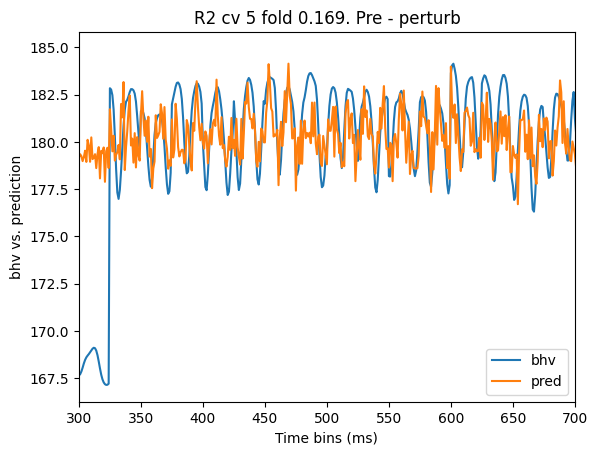

In [20]:
pre_perturb = np.stack(perturb_td_shuff.MOp_spikes_pca.values)[:, 25:50, :25]
bhv = np.stack(perturb_td_shuff.left_elbow.values)[:, 25:50, :]

r2s = cross_val_score(
    Ridge(0.01),
    pre_perturb.reshape(-1, pre_perturb.shape[-1]),
    bhv.reshape(-1, bhv.shape[-1]),
    cv=5,
    scoring=vw_r2_scorer
)


print(r2s.mean(), r2s.std())
y_pred = cross_val_predict(
    Ridge(0.01),
    pre_perturb.reshape(-1, pre_perturb.shape[-1]),
    bhv.reshape(-1, bhv.shape[-1]),
    cv=5,
)

fig, ax = plt.subplots()
ax.plot(bhv.reshape(-1, bhv.shape[-1])[:, 2], label='bhv')
ax.plot(y_pred[:, 2], label='pred')
ax.set_xlim(300, 700)
ax.set_xlabel('Time bins (ms)')
ax.set_ylabel('bhv vs. prediction')
ax.legend()
ax.set_title(f'R2 cv 5 fold {r2s.mean():.3f}. Pre - perturb')

0.0928472898822358 0.028445510898427433


Text(0.5, 1.0, 'R2 cv 5 fold 0.093. Post - perturb')

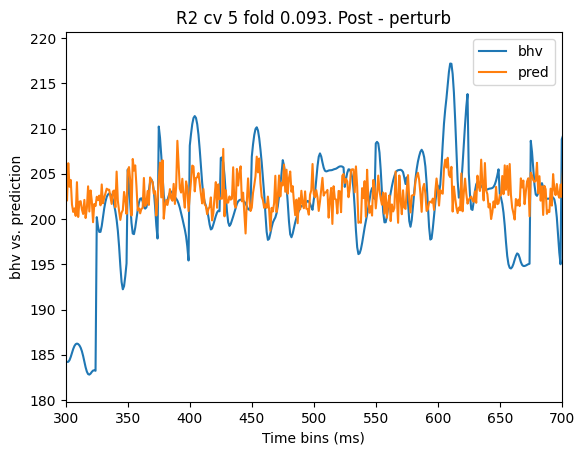

In [25]:
pre_perturb = np.stack(perturb_td_shuff.MOp_spikes_pca.values)[:, 100:125, :25]
bhv = np.stack(perturb_td_shuff.left_ankle.values)[:, 100:125, :]

r2s = cross_val_score(
    Ridge(0.01),
    pre_perturb.reshape(-1, pre_perturb.shape[-1]),
    bhv.reshape(-1, bhv.shape[-1]),
    cv=5,
    scoring=vw_r2_scorer
)


print(r2s.mean(), r2s.std())
y_pred = cross_val_predict(
    Ridge(0.01),
    pre_perturb.reshape(-1, pre_perturb.shape[-1]),
    bhv.reshape(-1, bhv.shape[-1]),
    cv=5,
)

fig, ax = plt.subplots()
ax.plot(bhv.reshape(-1, bhv.shape[-1])[:, 2], label='bhv')
ax.plot(y_pred[:, 2], label='pred')
ax.set_xlim(300, 700)
ax.set_xlabel('Time bins (ms)')
ax.set_ylabel('bhv vs. prediction')
ax.legend()
ax.set_title(f'R2 cv 5 fold {r2s.mean():.3f}. Post - perturb')

0.04809959243752835 0.0367693593610816


Text(0.5, 1.0, 'R2 cv 5 fold 0.048. Pre - perturb')

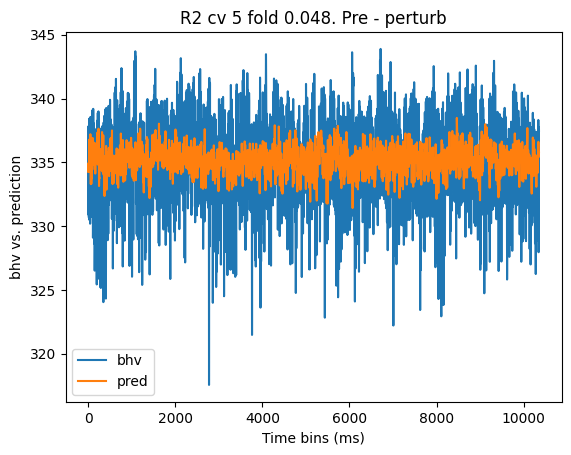

In [154]:
pre_perturb = np.stack(perturb_td_shuff.MOp_rates_pca.values)[:, 50:100, :25]
bhv = np.stack(perturb_td_shuff.left_ankle.values)[:, 50:100, :]

r2s = cross_val_score(
    Ridge(0.01),
    pre_perturb.reshape(-1, pre_perturb.shape[-1]),
    bhv.reshape(-1, bhv.shape[-1]),
    cv=5,
    scoring=vw_r2_scorer
)


print(r2s.mean(), r2s.std())
y_pred = cross_val_predict(
    Ridge(0.01),
    pre_perturb.reshape(-1, pre_perturb.shape[-1]),
    bhv.reshape(-1, bhv.shape[-1]),
    cv=5,
)

fig, ax = plt.subplots()
ax.plot(bhv.reshape(-1, bhv.shape[-1])[:, 2], label='bhv')
ax.plot(y_pred[:, 2], label='pred')
# ax.set_xlim(300, 700)
ax.set_xlabel('Time bins (ms)')
ax.set_ylabel('bhv vs. prediction')
ax.legend()
ax.set_title(f'R2 cv 5 fold {r2s.mean():.3f}. Pre - perturb')

-0.16288400574437584 0.11737696804340451


Text(0.5, 1.0, 'R2 cv 5 fold -0.163. Post - perturb. Rates')

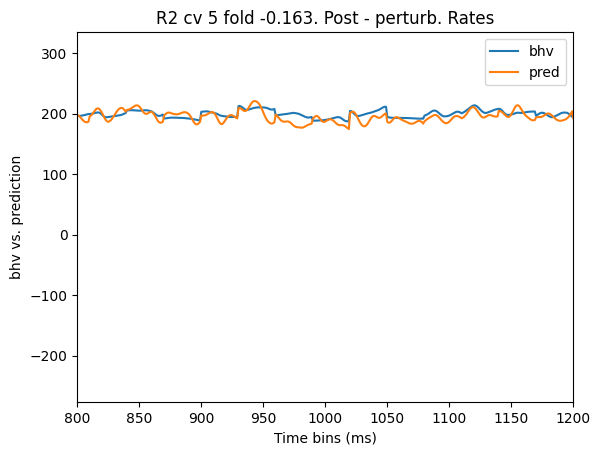

In [ ]:
pre_perturb = np.stack(perturb_td_shuff.MOp_rates_pca.values)[:, 220:250, :25]
bhv = np.stack(perturb_td_shuff.left_elbow.values)[:, 220:250, :]

r2s = cross_val_score(
    Ridge(0.01),
    pre_perturb.reshape(-1, pre_perturb.shape[-1]),
    bhv.reshape(-1, bhv.shape[-1]),
    cv=5,
    scoring=vw_r2_scorer
)

print(r2s.mean(), r2s.std())
y_pred = cross_val_predict(
    Ridge(0.01),
    pre_perturb.reshape(-1, pre_perturb.shape[-1]),
    bhv.reshape(-1, bhv.shape[-1]),
    cv=5,
)

fig, ax = plt.subplots()
ax.plot(bhv.reshape(-1, bhv.shape[-1])[:, 2], label='bhv')
ax.plot(y_pred[:, 2], label='pred')
ax.set_xlim(800, 1200)
ax.set_xlabel('Time bins (ms)')
ax.set_ylabel('bhv vs. prediction')
ax.legend()
ax.set_title(f'R2 cv 5 fold {r2s.mean():.3f}. Post - perturb. Rates')

Outlier bins clipped: 0 / 25650  (0.00%)
R² raw     : 0.276 ± 0.049
R² clipped : 0.276 ± 0.049


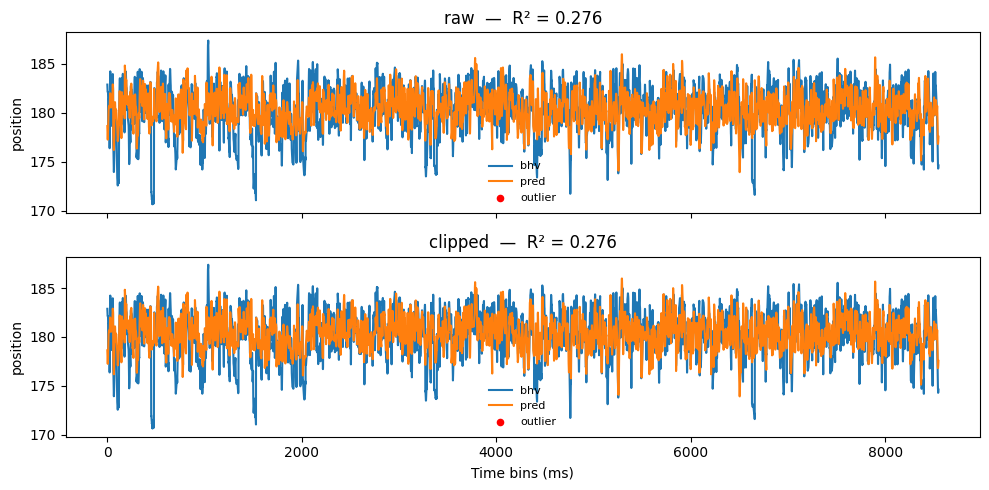

In [128]:
# ── Same cell but clip bhv outliers (z > 5) ─────────────────────────────────
pre_perturb = np.stack(perturb_td_shuff.MOp_rates_pca.values)[:, 220:250, :25]
bhv_raw = np.stack(perturb_td_shuff.left_elbow.values)[:, 220:250, :]

# clip per-dimension
z = (bhv_raw - bhv_raw.mean()) / (bhv_raw.std() + 1e-8)
bhv_clipped = np.clip(bhv_raw,
                      bhv_raw.mean() - 2 * bhv_raw.std(),
                      bhv_raw.mean() + 2 * bhv_raw.std())

outlier_mask = np.abs(z) > 2  # shape (trials, time, dims)
n_outliers = outlier_mask.sum()
print(f"Outlier bins clipped: {n_outliers} / {z.size}  ({100*n_outliers/z.size:.2f}%)")

r2s_raw     = cross_val_score(Ridge(0.01), pre_perturb.reshape(-1, pre_perturb.shape[-1]),
                               bhv_raw.reshape(-1, bhv_raw.shape[-1]), cv=5, scoring=vw_r2_scorer)
r2s_clipped = cross_val_score(Ridge(0.01), pre_perturb.reshape(-1, pre_perturb.shape[-1]),
                               bhv_clipped.reshape(-1, bhv_clipped.shape[-1]), cv=5, scoring=vw_r2_scorer)

print(f"R² raw     : {r2s_raw.mean():.3f} ± {r2s_raw.std():.3f}")
print(f"R² clipped : {r2s_clipped.mean():.3f} ± {r2s_clipped.std():.3f}")

y_pred_raw     = cross_val_predict(Ridge(0.01), pre_perturb.reshape(-1, pre_perturb.shape[-1]),
                                    bhv_raw.reshape(-1, bhv_raw.shape[-1]), cv=5)
y_pred_clipped = cross_val_predict(Ridge(0.01), pre_perturb.reshape(-1, pre_perturb.shape[-1]),
                                    bhv_clipped.reshape(-1, bhv_clipped.shape[-1]), cv=5)

DIM = 2  # which xyz dimension to plot
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
for ax, bhv_, pred_, label, r2s in zip(
    axes,
    [bhv_raw, bhv_clipped],
    [y_pred_raw, y_pred_clipped],
    ['raw', 'clipped'],
    [r2s_raw, r2s_clipped],
):
    bhv_flat = bhv_.reshape(-1, bhv_.shape[-1])
    ax.plot(bhv_flat[:, DIM], label='bhv')
    ax.plot(pred_[:, DIM], label='pred')

    # red dots on outlier positions (flattened)
    outlier_flat = outlier_mask.reshape(-1, outlier_mask.shape[-1])[:, DIM]
    outlier_idx  = np.where(outlier_flat)[0]
    ax.scatter(outlier_idx, bhv_flat[outlier_idx, DIM], color='red', s=20, zorder=5, label='outlier')

    # ax.set_xlim(800, 1200)
    ax.set_ylabel('position')
    ax.set_title(f'{label}  —  R² = {r2s.mean():.3f}')
    ax.legend(fontsize=8, frameon=False)

axes[-1].set_xlabel('Time bins (ms)')
plt.tight_layout()
plt.show()
